# Fast balanced RGB FPM reconstruction: complete field of view

This notebook starts from the working RGB centre-patch reconstruction, but removes the main full-FOV bottleneck. Each DNG is demosaiced, dark-subtracted and exposure/gain-normalised only once per colour. The full-frame results are cached on disk and every reconstruction tile is then read from that cache.

The default settings are intentionally **balanced rather than maximum quality**: 512-pixel tiles, low overlap, shells 0-6, two pupil stages and four iterations per stage. The DR and EPRY update equations remain the same. An optional CuPy backend is used automatically when available.

> No reconstruction code can guarantee a sharp image when calibration, focus, dark subtraction or measurements are inconsistent. This version is designed to make a complete test practical before committing to a maximum-quality run.


## 1. Imports and settings


In [1]:
#!/usr/bin/env python3
"""
Fast balanced RGB Fourier ptychographic reconstruction for the complete
camera field of view.

The working centre-patch preprocessing, LED calibration, DR amplitude
replacement and EPRY quasi-Newton updates are retained. The expensive DNG
decode/dark/exposure-normalisation pass is performed only once per colour and
stored in a resumable disk cache. The default balanced run uses shells 0-6,
two pupil stages and four iterations per stage. CuPy is used automatically
when available; otherwise SciPy FFTs use the CPU.

No reconstruction can guarantee sharpness when calibration, focus, overlap,
motion or measurements are inconsistent. Calibration, convergence and tile
diagnostics are saved for inspection.
"""

from __future__ import annotations

import csv
import json
import math
import re
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import convolve, gaussian_gradient_magnitude
from scipy.signal import fftconvolve

try:
    import cv2
except Exception:
    cv2 = None

try:
    import rawpy
except Exception:
    rawpy = None

try:
    from tqdm import tqdm
except Exception:
    def tqdm(values, **kwargs):
        return values


# =============================================================================
# USER SETTINGS
# =============================================================================

# Root folder containing separate RED, GREEN and BLUE acquisition folders.
# Expected default structure:
#   D:\FPM_results\14_07_26\RED
#   D:\FPM_results\14_07_26\GREEN
#   D:\FPM_results\14_07_26\BLUE
RGB_ROOT_DIR = Path(r"C:\Users\kshlo\Desktop\FPM\John Code\Sequential")

RGB_CHANNELS = {
    "red": {
        "data_dir": RGB_ROOT_DIR / "RED",
        "sensor_channel_index": 0,
        "wavelength_um": 0.630,
        "results_folder_name": "results_red_full_fov_fast_balanced",
    },
    "green": {
        "data_dir": RGB_ROOT_DIR / "GREEN",
        "sensor_channel_index": 1,
        "wavelength_um": 0.530,
        "results_folder_name": "results_green_full_fov_fast_balanced",
    },
    "blue": {
        "data_dir": RGB_ROOT_DIR / "BLUE",
        "sensor_channel_index": 2,
        "wavelength_um": 0.470,
        "results_folder_name": "results_blue_full_fov_fast_balanced",
    },
}

RGB_RUN_ORDER = ("red", "green", "blue")
RGB_COMBINED_RESULTS_DIR = RGB_ROOT_DIR / "results_rgb_full_fov_fast_balanced"

# Metadata filename priority inside each RED/GREEN/BLUE acquisition folder.
# If none of these exact names exists, the loader falls back to metadata*.csv.
PREFERRED_METADATA_FILENAMES = (
    "metadata_updated_shell6_7.csv",
    "metadata.csv",
    "metadata_red.csv",
    "metadata_green.csv",
    "metadata_blue.csv",
)


# Set this to a subset such as ("red", "blue") when the green reconstruction
# already exists and should be reused.
COLOURS_TO_RECONSTRUCT = RGB_RUN_ORDER

# When True, an existing completed full-FOV amplitude is reused instead of
# rerunning that colour.
REUSE_EXISTING_FULL_FOV_RECONSTRUCTIONS = False

# The original working centre patch is retained as the reference tile used for
# LED self-calibration. ROI_SIZE is also the size of every full-FOV tile.
ROI_SIZE = 512
ROI_CENTER = (1232, 1640)  # (row, column)
SEED_IMAGE_INDEX = 0

# Full-FOV wrapper settings. None of these alter the DR/EPRY equations.
TILE_OVERLAP_PX = 16
RESUME_EXISTING_TILES = True
SAVE_INDIVIDUAL_TILE_PREVIEWS = True

# Fast-path settings. The cache stores dark-subtracted, exposure/gain-normalised
# full frames before the tile-specific global scale is applied. Therefore each
# tile keeps the same normalisation behaviour as the working centre-patch code.
USE_GPU_IF_AVAILABLE = True
USE_SINGLE_PRECISION = True
FFT_WORKERS = -1  # all CPU cores when the CPU fallback is used
CACHE_DTYPE = np.float32
DELETE_PREPROCESSING_CACHE_AFTER_COMPLETED_COLOUR = True
CACHE_FLUSH_EVERY_N_IMAGES = 4

# The balanced default reconstructs shells 0-6 (196 LEDs). For a later
# maximum-quality run, change MAX_RECONSTRUCTION_SHELL to 7 and consider
# EPRY_STAGES=3, ITERATIONS_PER_STAGE=6 after the balanced result is verified.

# The amplitude array is always saved because it is required for RGB fusion.
# These optional arrays are much larger and are not required for the final RGB.
SAVE_FULL_FOV_PHASE_ARRAY = False
SAVE_FULL_FOV_COMPLEX_ARRAY = False
DELETE_STITCH_ACCUMULATORS_AFTER_SAVE = True

# Sensor and optical values.
BAYER_PATTERN = "BGGR"
NATIVE_PIXEL_UM = 1.12
MAGNIFICATION = 1.062
OBJECTIVE_NA = 0.095
DPIX_OBJECT_UM = NATIVE_PIXEL_UM / MAGNIFICATION

# Unicorn HAT HD geometry and capture ordering.
LED_GRID = 16
LED_PITCH_UM = 3300.0
LED_DISTANCE_UM = 61800.0
LED_START_XY = (7, 7)
LED_ARRAY_CENTER = "auto"
EXPECTED_IMAGE_COUNT = 256
SHELL_BOUNDARIES = (4, 16, 36, 64, 100, 144, 196)

# Metadata normally provides actual exposure and gain values. These are only
# fallbacks when metadata entries are missing.
FALLBACK_EXPOSURE_US = (
    50000.0,
    70000.0,
    100000.0,
    300000.0,
    450000.0,
    800000.0,
    9000000.0,
    11000000.0,
)

USE_DARK_SUBTRACTION = True
NORMALISE_BY_ANALOGUE_GAIN = True
STRICT_CAPTURE_VALIDATION = True

# Active globals are changed automatically before each colour reconstruction.
ACTIVE_COLOUR = "green"
ACTIVE_SENSOR_CHANNEL_INDEX = 1
DATA_DIR = RGB_CHANNELS[ACTIVE_COLOUR]["data_dir"]
WAVELENGTH_UM = RGB_CHANNELS[ACTIVE_COLOUR]["wavelength_um"]
RESULTS_FOLDER_NAME = RGB_CHANNELS[ACTIVE_COLOUR]["results_folder_name"]


def set_active_colour(colour: str) -> None:
    """Switch all wavelength/channel/path globals for one monochromatic run."""
    global ACTIVE_COLOUR
    global ACTIVE_SENSOR_CHANNEL_INDEX
    global DATA_DIR
    global WAVELENGTH_UM
    global RESULTS_FOLDER_NAME

    colour = colour.lower().strip()

    if colour not in RGB_CHANNELS:
        raise ValueError(
            f"Unsupported colour {colour!r}. "
            f"Choose from {tuple(RGB_CHANNELS)}."
        )

    configuration = RGB_CHANNELS[colour]

    ACTIVE_COLOUR = colour
    ACTIVE_SENSOR_CHANNEL_INDEX = int(
        configuration["sensor_channel_index"]
    )
    DATA_DIR = Path(configuration["data_dir"])
    WAVELENGTH_UM = float(configuration["wavelength_um"])
    RESULTS_FOLDER_NAME = str(
        configuration["results_folder_name"]
    )

    print()
    print("=" * 80)
    print(f"ACTIVE COLOUR: {ACTIVE_COLOUR.upper()}")
    print("Data folder:", DATA_DIR)
    print("Sensor RGB channel index:", ACTIVE_SENSOR_CHANNEL_INDEX)
    print("Illumination wavelength:", WAVELENGTH_UM, "um")
    print("Results folder:", RESULTS_FOLDER_NAME)
    print("=" * 80)


set_active_colour("green")


if not PREFERRED_METADATA_FILENAMES:
    raise RuntimeError(
        "PREFERRED_METADATA_FILENAMES must contain at least one filename."
    )

print(
    "Metadata filename priority:",
    PREFERRED_METADATA_FILENAMES,
)

# FFT-circle LED calibration.
GEOMETRY_MODE = "safe_auto"  # "safe_auto", "selfcal", or "design"
AXIS_SIGN_CANDIDATES = ((1, 1), (1, -1), (-1, 1), (-1, -1))
CENTER_SEARCH_OFFSETS = (-0.5, 0.0, 0.5)
CALIB_MIN_RADIUS_FRACTION = 0.35
CALIB_MAX_RADIUS_FRACTION = 0.82
CALIB_SEARCH_RADIUS_PX = 12
CALIB_RING_WIDTH_PX = 1.6
CALIB_MIN_CONFIDENCE = 3.2
CALIB_MAX_PAIR_ERROR_PX = 4.0
MIN_CALIBRATION_DETECTIONS = 7
MIN_ACCEPTED_CALIBRATION_POINTS = 8
MAX_ACCEPTED_CALIBRATION_RESIDUAL_PX = 4.5
RANSAC_REPROJECTION_THRESHOLD_PX = 3.0
SAVE_CALIBRATION_OVERLAYS = True
MAX_CALIBRATION_OVERLAYS = 20

# Paper-aligned EPRY recovery used unchanged for every tile.
EPRY_STAGES = 2
ITERATIONS_PER_STAGE = 4
ENABLE_PUPIL_RECOVERY = True
PUPIL_UPDATE_START_ITERATION = 2
ALPHA_OBJECT_START = 0.85
ALPHA_OBJECT_END = 0.20
BETA_PUPIL_START = 0.18
BETA_PUPIL_END = 0.035
OBJECT_REGULARISATION_FRACTION = 1e-3
PUPIL_REGULARISATION_FRACTION = 1e-3
OBJECT_GRID_PAD_PX = 8

# Use every shell at full physical strength. There is no shell down-weighting.
MAX_RECONSTRUCTION_SHELL = 6

# Scientific output is saved without cosmetic sharpening. A separate display-only
# image is also saved for convenient inspection.
SAVE_DISPLAY_SHARPENED_IMAGE = True
DISPLAY_UNSHARP_SIGMA_PX = 1.0
DISPLAY_UNSHARP_AMOUNT = 0.45



ACTIVE COLOUR: GREEN
Data folder: C:\Users\kshlo\Desktop\FPM\John Code\Sequential\GREEN
Sensor RGB channel index: 1
Illumination wavelength: 0.53 um
Results folder: results_green_full_fov_fast_balanced
Metadata filename priority: ('metadata_updated_shell6_7.csv', 'metadata.csv', 'metadata_red.csv', 'metadata_green.csv', 'metadata_blue.csv')


## 2. Fourier helpers

In [2]:
# =============================================================================
# Fourier and generic helpers
# =============================================================================

def FT(image: np.ndarray) -> np.ndarray:
    return np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(image)))


def IFT(spectrum: np.ndarray) -> np.ndarray:
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(spectrum)))


def next_even(value: float) -> int:
    integer = int(math.ceil(float(value)))
    return integer if integer % 2 == 0 else integer + 1


def stretch(image: np.ndarray, low: float = 0.5, high: float = 99.5, gamma: float = 1.0) -> np.ndarray:
    array = np.asarray(image, np.float32)
    finite = array[np.isfinite(array)]
    if finite.size == 0:
        return np.zeros_like(array, dtype=np.float32)
    lo, hi = np.percentile(finite, [low, high])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return np.zeros_like(array, dtype=np.float32)
    result = np.clip((array - lo) / (hi - lo), 0.0, 1.0)
    if gamma != 1.0:
        result = result ** float(gamma)
    return result.astype(np.float32)


def save_uint8(path: Path, image: np.ndarray, low: float = 0.5, high: float = 99.5, gamma: float = 1.0) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    rendered = np.round(255.0 * stretch(image, low, high, gamma)).astype(np.uint8)
    Image.fromarray(rendered).save(path)


def shell_index_from_image_number(image_number: int) -> int:
    return int(sum(int(image_number) >= boundary for boundary in SHELL_BOUNDARIES))


def spiral_led_coordinates(
    grid: int = LED_GRID,
    start_xy: Tuple[int, int] = LED_START_XY,
) -> np.ndarray:
    """Exact centre-out spiral used by capture_iter_2.py."""
    x, y = map(int, start_xy)
    dx, dy = -1, 0
    coordinates = []
    for _ in range(grid * grid):
        coordinates.append((x, y))
        if x == y or (x + y == 15 and x <= 7) or (x + y == 14 and x > 7):
            dx, dy = dy, -dx
        x, y = x + dx, y + dy
    coordinates_array = np.asarray(coordinates, dtype=int)
    if coordinates_array.shape != (grid * grid, 2):
        raise RuntimeError("Spiral generator returned an unexpected shape.")
    if len({tuple(value) for value in coordinates_array.tolist()}) != grid * grid:
        raise RuntimeError("Spiral generator contains duplicate LED coordinates.")
    if coordinates_array.min() < 0 or coordinates_array.max() >= grid:
        raise RuntimeError("Spiral generator left the LED grid.")
    return coordinates_array


def theoretical_adjacent_overlap_fraction() -> float:
    """Circular pupil-overlap fraction for one LED pitch near the array centre."""
    radius = OBJECTIVE_NA / WAVELENGTH_UM
    illumination_step = (
        LED_PITCH_UM / math.sqrt(LED_PITCH_UM ** 2 + LED_DISTANCE_UM ** 2)
    ) / WAVELENGTH_UM
    if illumination_step >= 2.0 * radius:
        return 0.0
    overlap_area = (
        2.0 * radius * radius * math.acos(illumination_step / (2.0 * radius))
        - 0.5 * illumination_step * math.sqrt(4.0 * radius * radius - illumination_step ** 2)
    )
    return overlap_area / (math.pi * radius * radius)


## 3. DNG loading and dark subtraction

In [3]:
# =============================================================================
# Linear DNG demosaicing and metadata loading
# =============================================================================

def load_dng_channel(
    path: Path,
    channel_index: Optional[int] = None,
) -> np.ndarray:
    """
    Load one linear demosaiced RGB sensor channel.

    The matched channel is selected automatically:
      red LED data   -> red camera channel   (index 0)
      green LED data -> green camera channel (index 1)
      blue LED data  -> blue camera channel  (index 2)
    """
    if rawpy is None:
        raise ImportError(
            "rawpy is required. Install with: pip install rawpy"
        )

    if channel_index is None:
        channel_index = ACTIVE_SENSOR_CHANNEL_INDEX

    with rawpy.imread(str(path)) as raw:
        rgb = raw.postprocess(
            demosaic_algorithm=rawpy.DemosaicAlgorithm.LINEAR,
            no_auto_bright=True,
            output_bps=16,
            gamma=(1, 1),
            use_camera_wb=False,
            user_wb=[1, 1, 1, 1],
        )

    if channel_index not in (0, 1, 2):
        raise ValueError(
            f"RGB channel index must be 0, 1 or 2; got {channel_index}."
        )

    return rgb[..., channel_index].astype(np.float32)


def load_channel_image(path: Path) -> np.ndarray:
    """Load the currently active red, green or blue sensor channel."""
    suffix = path.suffix.lower()

    if suffix in {".dng", ".raw"}:
        return load_dng_channel(path)

    if suffix == ".npy":
        array = np.load(path)

        if array.ndim == 3:
            return array[
                ..., ACTIVE_SENSOR_CHANNEL_INDEX
            ].astype(np.float32)

        return array.astype(np.float32)

    array = np.asarray(Image.open(path))

    if array.ndim == 3:
        return array[
            ..., ACTIVE_SENSOR_CHANNEL_INDEX
        ].astype(np.float32)

    return array.astype(np.float32)



def first_value(row: Dict[str, str], names: Sequence[str], default: Optional[str] = None) -> Optional[str]:
    normalised = {str(key).strip().lower(): value for key, value in row.items() if key is not None}
    for name in names:
        value = normalised.get(name.lower())
        if value is not None and str(value).strip() != "":
            return str(value).strip()
    return default


def float_or_none(value: Optional[str]) -> Optional[float]:
    if value is None or str(value).strip() == "":
        return None
    try:
        return float(str(value).strip())
    except ValueError:
        return None


def find_metadata_csv(data_dir: Path) -> Path:
    colour_upper = ACTIVE_COLOUR.upper()
    colour_lower = ACTIVE_COLOUR.lower()

    folders = (
        data_dir,
        data_dir / colour_upper,
        data_dir / colour_lower,
        data_dir / "Sequential" / colour_upper,
        data_dir / "Sequential" / colour_lower,
    )
    for folder in folders:
        if not folder.is_dir():
            continue
        for filename in PREFERRED_METADATA_FILENAMES:
            candidate = folder / filename
            if candidate.exists():
                return candidate
        alternatives = sorted(folder.glob("metadata*.csv"))
        if alternatives:
            return alternatives[0]
    raise FileNotFoundError(f"No metadata CSV was found from: {data_dir}")


def resolve_path(csv_path: Path, value: str) -> Path:
    path = Path(value)
    return path if path.is_absolute() else csv_path.parent / path


def effective_setting(
    row: Dict[str, str],
    actual_names: Sequence[str],
    requested_names: Sequence[str],
    fallback: float,
) -> float:
    actual = float_or_none(first_value(row, actual_names))
    requested = float_or_none(first_value(row, requested_names))
    if actual is not None and actual > 0:
        return float(actual)
    if requested is not None and requested > 0:
        return float(requested)
    return float(fallback)


def read_capture_metadata(data_dir: Path) -> Dict:
    csv_path = find_metadata_csv(data_dir)
    with csv_path.open("r", newline="", encoding="utf-8-sig") as handle:
        rows = list(csv.DictReader(handle))

    samples = []
    dark_by_filename: Dict[str, Dict] = {}
    dark_by_shell: Dict[int, Dict] = {}

    for row_number, row in enumerate(rows, start=2):
        frame_type = (first_value(row, ("frame_type", "type"), "") or "").lower()
        filename = first_value(row, ("filename", "file", "path", "image_path", "name"))
        if filename is None:
            continue

        shell_value = float_or_none(first_value(row, ("shell_index", "shell", "shell_id")))
        image_value = float_or_none(first_value(row, ("image_index", "image_number", "index", "img_no")))
        is_dark = "dark" in frame_type or "darkframe" in filename.lower()

        if is_dark:
            if shell_value is None:
                raise ValueError(f"Dark frame on CSV line {row_number} has no shell index.")
            shell_index = int(round(shell_value))
            dark_record = {
                "path": resolve_path(csv_path, filename),
                "shell_index": shell_index,
                "exposure_us": effective_setting(
                    row,
                    ("actual_exposure_us", "actual_exposure_time_us"),
                    ("requested_exposure_us", "exposure_us"),
                    FALLBACK_EXPOSURE_US[shell_index],
                ),
                "gain": effective_setting(
                    row,
                    ("actual_analogue_gain", "actual_analog_gain"),
                    ("requested_analogue_gain", "requested_analog_gain"),
                    1.0,
                ),
            }
            dark_by_filename[Path(filename).name.lower()] = dark_record
            dark_by_shell[shell_index] = dark_record
            continue

        if image_value is None:
            match = re.search(r"ImgNo[_\- ]*(\d+)", filename, flags=re.IGNORECASE)
            if match is None:
                raise ValueError(f"Sample on CSV line {row_number} has no image index.")
            image_index = int(match.group(1))
        else:
            image_index = int(round(image_value))

        shell_index = (
            int(round(shell_value))
            if shell_value is not None
            else shell_index_from_image_number(image_index)
        )
        led_x = float_or_none(first_value(row, ("led_x", "x", "ledx")))
        led_y = float_or_none(first_value(row, ("led_y", "y", "ledy")))
        if led_x is None or led_y is None:
            raise ValueError(f"Sample on CSV line {row_number} has invalid LED coordinates.")

        exposure_us = effective_setting(
            row,
            ("actual_exposure_us", "actual_exposure_time_us"),
            ("requested_exposure_us", "exposure_us"),
            FALLBACK_EXPOSURE_US[shell_index],
        )
        gain = effective_setting(
            row,
            ("actual_analogue_gain", "actual_analog_gain"),
            ("requested_analogue_gain", "requested_analog_gain"),
            1.0,
        )
        associated_dark = first_value(row, ("associated_darkframe", "darkframe", "dark_filename"), "")

        samples.append({
            "image_index": image_index,
            "path": resolve_path(csv_path, filename),
            "led_x": int(round(led_x)),
            "led_y": int(round(led_y)),
            "shell_index": shell_index,
            "exposure_us": float(exposure_us),
            "gain": float(gain),
            "associated_dark": Path(associated_dark).name.lower() if associated_dark else "",
        })

    samples.sort(key=lambda item: item["image_index"])

    if len(samples) != EXPECTED_IMAGE_COUNT:
        raise ValueError(f"Expected {EXPECTED_IMAGE_COUNT} samples, found {len(samples)}.")
    indices = [item["image_index"] for item in samples]
    if indices != list(range(EXPECTED_IMAGE_COUNT)):
        raise ValueError("Metadata must contain image_index 0 through 255 exactly once.")

    expected_coordinates = spiral_led_coordinates()
    coordinate_mismatches = []
    for sample in samples:
        expected = tuple(expected_coordinates[sample["image_index"]])
        observed = (sample["led_x"], sample["led_y"])
        if expected != observed:
            coordinate_mismatches.append((sample["image_index"], expected, observed))
        expected_shell = shell_index_from_image_number(sample["image_index"])
        if sample["shell_index"] != expected_shell:
            raise ValueError(
                f"Image {sample['image_index']} has shell {sample['shell_index']}; "
                f"capture_iter_2 requires shell {expected_shell}."
            )

    if coordinate_mismatches:
        message = f"{len(coordinate_mismatches)} LED coordinates disagree with the capture spiral."
        if STRICT_CAPTURE_VALIDATION:
            raise ValueError(message + f" First mismatch: {coordinate_mismatches[0]}")
        print("WARNING:", message)

    missing_paths = [str(item["path"]) for item in samples if not item["path"].exists()]
    if missing_paths:
        raise FileNotFoundError(f"{len(missing_paths)} sample files are missing. First: {missing_paths[0]}")

    if USE_DARK_SUBTRACTION:
        for shell_index in range(8):
            if shell_index not in dark_by_shell:
                raise ValueError(f"No dark frame is available for shell {shell_index}.")
            if not dark_by_shell[shell_index]["path"].exists():
                raise FileNotFoundError(str(dark_by_shell[shell_index]["path"]))

    print(f"Metadata selected: {csv_path}")
    print("Capture validation: 256 images and the exact 16 x 16 centre-out spiral.")
    print(
        "Shell 6/7 gains:",
        sorted({item["gain"] for item in samples if item["shell_index"] == 6}),
        sorted({item["gain"] for item in samples if item["shell_index"] == 7}),
    )

    return {
        "csv_path": csv_path,
        "samples": samples,
        "dark_by_filename": dark_by_filename,
        "dark_by_shell": dark_by_shell,
    }


def crop_center(image: np.ndarray) -> Tuple[np.ndarray, Tuple[int, int, int, int]]:
    height, width = image.shape
    if ROI_SIZE > height or ROI_SIZE > width:
        raise ValueError(f"ROI_SIZE={ROI_SIZE} exceeds image shape {image.shape}.")
    if ROI_CENTER == "auto":
        centre_row, centre_col = height // 2, width // 2
    else:
        centre_row, centre_col = int(ROI_CENTER[0]), int(ROI_CENTER[1])
    half = ROI_SIZE // 2
    row0 = int(np.clip(centre_row - half, 0, height - ROI_SIZE))
    col0 = int(np.clip(centre_col - half, 0, width - ROI_SIZE))
    return image[row0:row0 + ROI_SIZE, col0:col0 + ROI_SIZE], (row0, col0, ROI_SIZE, ROI_SIZE)


def preview_centre_roi() -> Dict:
    """Show the geometric centre crop before the long reconstruction."""
    metadata = read_capture_metadata(DATA_DIR)
    seed_path = metadata["samples"][SEED_IMAGE_INDEX]["path"]
    full_image = load_channel_image(seed_path)
    roi_image, (row0, col0, height, width) = crop_center(full_image)

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))

    axes[0].imshow(stretch(full_image, 0.5, 99.5), cmap="gray")
    rectangle = plt.Rectangle(
        (col0, row0),
        width,
        height,
        fill=False,
        linewidth=2,
    )
    axes[0].add_patch(rectangle)
    axes[0].set_title(
        f"Full centre-LED image with centred ROI\n"
        f"row={row0}:{row0 + height}, col={col0}:{col0 + width}"
    )
    axes[0].axis("off")

    axes[1].imshow(stretch(roi_image, 0.5, 99.5), cmap="gray")
    axes[1].set_title(f"Geometric centre crop ({height} x {width})")
    axes[1].axis("off")

    fig.tight_layout()
    plt.show()

    return {
        "seed_path": str(seed_path),
        "roi_center": "auto",
        "roi_bounds": (row0, col0, height, width),
        "roi_shape": tuple(roi_image.shape),
    }


def load_preprocessed_stack(metadata: Dict) -> Tuple[np.ndarray, np.ndarray, np.ndarray, Dict]:
    samples = metadata["samples"]
    seed_full = load_channel_image(samples[SEED_IMAGE_INDEX]["path"])
    seed_crop, roi = crop_center(seed_full)
    row0, col0, size, _ = roi

    stack = np.zeros((EXPECTED_IMAGE_COUNT, size, size), dtype=np.float32)
    dark_cache: Dict[Path, np.ndarray] = {}
    raw_seed = seed_crop.copy()
    dark_subtracted_seed = None

    for sample in tqdm(samples, desc="demosaic/dark/exposure-normalise"):
        image = load_channel_image(sample["path"])
        image_crop = image[row0:row0 + size, col0:col0 + size]

        dark_crop = 0.0
        if USE_DARK_SUBTRACTION:
            dark_record = None
            if sample["associated_dark"]:
                dark_record = metadata["dark_by_filename"].get(sample["associated_dark"])
            if dark_record is None:
                dark_record = metadata["dark_by_shell"][sample["shell_index"]]

            dark_path = dark_record["path"]
            if dark_path not in dark_cache:
                dark_image = load_channel_image(dark_path)
                dark_cache[dark_path] = dark_image[row0:row0 + size, col0:col0 + size]
            dark_crop = dark_cache[dark_path]

            # The actual dark exposure recorded in metadata can lag the requested
            # shell change by one frame. The dark is therefore scaled below using
            # the actual exposure x gain ratio before subtraction.

        if USE_DARK_SUBTRACTION:
            sample_effective = sample["exposure_us"] * sample["gain"]
            dark_effective = dark_record["exposure_us"] * dark_record["gain"]
            dark_scale = sample_effective / max(dark_effective, 1e-12)
            signal = np.clip(image_crop - dark_crop * dark_scale, 0.0, None)
        else:
            signal = np.clip(image_crop, 0.0, None)

        denominator = sample["exposure_us"]
        if NORMALISE_BY_ANALOGUE_GAIN:
            denominator *= sample["gain"]
        stack[sample["image_index"]] = signal / max(float(denominator), 1e-12)

        if sample["image_index"] == SEED_IMAGE_INDEX:
            dark_subtracted_seed = signal.copy()

    # One common scale only. Relative intensity among all LEDs is preserved.
    scale = float(np.percentile(stack[SEED_IMAGE_INDEX], 99.5))
    if not np.isfinite(scale) or scale <= 0:
        scale = float(np.percentile(stack, 99.5))
    stack /= max(scale, 1e-12)

    led_x = np.asarray([item["led_x"] for item in samples], dtype=np.int32)
    led_y = np.asarray([item["led_y"] for item in samples], dtype=np.int32)

    info = {
        "roi": roi,
        "metadata_csv": str(metadata["csv_path"]),
        "raw_seed": raw_seed,
        "dark_subtracted_seed": dark_subtracted_seed,
        "global_scale": scale,
        "effective_exposure_gain": [
            item["exposure_us"] * (item["gain"] if NORMALISE_BY_ANALOGUE_GAIN else 1.0)
            for item in samples
        ],
        "shell_gains": {
            str(shell): sorted({item["gain"] for item in samples if item["shell_index"] == shell})
            for shell in range(8)
        },
    }
    return stack.astype(np.float32), led_x, led_y, info


## 4. LED geometry and calibration

In [4]:
# =============================================================================
# LED geometry and FFT-circle self-calibration
# =============================================================================

def initial_led_center() -> Tuple[float, float]:
    if LED_ARRAY_CENTER == "auto":
        centre = (LED_GRID - 1) / 2.0
        return centre, centre
    return float(LED_ARRAY_CENTER[0]), float(LED_ARRAY_CENTER[1])


def build_design_geometry(
    led_x: np.ndarray,
    led_y: np.ndarray,
    centre_led: Tuple[float, float],
    axis_signs: Tuple[int, int],
    roi_size: int,
) -> Dict:
    sign_x, sign_y = axis_signs
    physical_x = (led_x.astype(np.float64) - centre_led[0]) * LED_PITCH_UM * sign_x
    physical_y = (led_y.astype(np.float64) - centre_led[1]) * LED_PITCH_UM * sign_y
    distance = np.sqrt(physical_x ** 2 + physical_y ** 2 + LED_DISTANCE_UM ** 2)
    na_x = physical_x / distance
    na_y = physical_y / distance
    frequency_step = 1.0 / (roi_size * DPIX_OBJECT_UM)
    kx = (na_x / WAVELENGTH_UM) / frequency_step
    ky = (na_y / WAVELENGTH_UM) / frequency_step
    pupil_radius = (OBJECTIVE_NA / WAVELENGTH_UM) / frequency_step
    maximum_shift = float(np.max(np.hypot(kx, ky)))
    object_size = next_even(roi_size + 2.0 * maximum_shift + 2.0 * OBJECT_GRID_PAD_PX)
    return {
        "kx_design": kx.copy(),
        "ky_design": ky.copy(),
        "kx": kx.copy(),
        "ky": ky.copy(),
        "pupil_radius_px": float(pupil_radius),
        "centre_led": tuple(map(float, centre_led)),
        "axis_signs": tuple(map(int, axis_signs)),
        "n_object": int(object_size),
        "upsample": float(object_size / roi_size),
        "calibration_status": "design",
        "calibration_records": [],
        "transform_type": "none",
        "transform_matrix": None,
    }


def ring_kernel(radius: float, width: float) -> np.ndarray:
    padding = int(math.ceil(radius + 4.0 * width + 3.0))
    yy, xx = np.indices((2 * padding + 1, 2 * padding + 1))
    radial = np.hypot(xx - padding, yy - padding)
    kernel = np.exp(-0.5 * ((radial - radius) / max(width, 1e-6)) ** 2).astype(np.float32)
    kernel -= np.mean(kernel)
    kernel /= np.sqrt(np.sum(kernel * kernel)) + 1e-12
    return kernel


def quadratic_subpixel(minus: float, centre: float, plus: float) -> float:
    denominator = minus - 2.0 * centre + plus
    if not np.isfinite(denominator) or abs(denominator) < 1e-12:
        return 0.0
    return float(np.clip(0.5 * (minus - plus) / denominator, -1.0, 1.0))


def local_peak(
    correlation: np.ndarray,
    predicted_row: float,
    predicted_col: float,
    search_radius: int,
) -> Optional[Tuple[float, float, float, float]]:
    height, width = correlation.shape
    centre_row = int(round(predicted_row))
    centre_col = int(round(predicted_col))
    row1 = max(0, centre_row - search_radius)
    row2 = min(height, centre_row + search_radius + 1)
    col1 = max(0, centre_col - search_radius)
    col2 = min(width, centre_col + search_radius + 1)
    if row2 <= row1 or col2 <= col1:
        return None

    window = correlation[row1:row2, col1:col2]
    local_row, local_col = np.unravel_index(int(np.argmax(window)), window.shape)
    row = row1 + int(local_row)
    col = col1 + int(local_col)
    peak = float(correlation[row, col])
    median = float(np.median(window))
    mad = float(np.median(np.abs(window - median))) + 1e-12
    confidence = (peak - median) / (1.4826 * mad + 1e-12)

    row_subpixel = float(row)
    col_subpixel = float(col)
    if 1 <= row < height - 1 and 1 <= col < width - 1:
        row_subpixel += quadratic_subpixel(
            float(correlation[row - 1, col]),
            peak,
            float(correlation[row + 1, col]),
        )
        col_subpixel += quadratic_subpixel(
            float(correlation[row, col - 1]),
            peak,
            float(correlation[row, col + 1]),
        )
    return row_subpixel, col_subpixel, peak, float(confidence)


def fft_circle_feature(intensity: np.ndarray) -> np.ndarray:
    image = np.asarray(intensity, np.float32)
    image = image - np.median(image)
    window = np.hanning(image.shape[0])[:, None] * np.hanning(image.shape[1])[None, :]
    spectrum = np.log1p(np.abs(FT(image * window)))
    feature = gaussian_gradient_magnitude(stretch(spectrum, 1.0, 99.8), sigma=0.9)
    centre = image.shape[0] // 2
    yy, xx = np.indices(image.shape)
    feature[np.hypot(xx - centre, yy - centre) < 4.0] = 0.0
    feature /= np.percentile(feature, 99.5) + 1e-12
    return np.nan_to_num(feature, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


def detect_fft_circle_pair(
    image: np.ndarray,
    pupil_radius: float,
    predicted_kx: float,
    predicted_ky: float,
    kernel_cache: Dict,
) -> Optional[Dict]:
    cache_key = (round(pupil_radius, 2), round(CALIB_RING_WIDTH_PX, 2))
    if cache_key not in kernel_cache:
        kernel_cache[cache_key] = ring_kernel(pupil_radius, CALIB_RING_WIDTH_PX)

    feature = fft_circle_feature(image)
    correlation = fftconvolve(
        feature,
        kernel_cache[cache_key][::-1, ::-1],
        mode="same",
    )
    centre = image.shape[0] // 2
    plus = local_peak(
        correlation,
        centre + predicted_ky,
        centre + predicted_kx,
        CALIB_SEARCH_RADIUS_PX,
    )
    minus = local_peak(
        correlation,
        centre - predicted_ky,
        centre - predicted_kx,
        CALIB_SEARCH_RADIUS_PX,
    )
    if plus is None or minus is None:
        return None
    if plus[3] < CALIB_MIN_CONFIDENCE or minus[3] < CALIB_MIN_CONFIDENCE:
        return None

    plus_shift = np.array([plus[1] - centre, plus[0] - centre], dtype=np.float64)
    minus_shift = np.array([-(minus[1] - centre), -(minus[0] - centre)], dtype=np.float64)
    pair_error = float(np.linalg.norm(plus_shift - minus_shift))
    if pair_error > CALIB_MAX_PAIR_ERROR_PX:
        return None

    measured = 0.5 * (plus_shift + minus_shift)
    return {
        "kx": float(measured[0]),
        "ky": float(measured[1]),
        "confidence": float(min(plus[3], minus[3])),
        "pair_error_px": pair_error,
        "plus": plus,
        "minus": minus,
        "feature": feature,
        "correlation": correlation,
    }


def apply_projective_transform(points: np.ndarray, matrix: np.ndarray) -> np.ndarray:
    homogeneous = np.column_stack([points, np.ones(len(points))])
    transformed = homogeneous @ matrix.T
    denominator = transformed[:, 2:3]
    if np.any(np.abs(denominator) < 1e-12):
        raise ValueError("Projective transform produced points at infinity.")
    return transformed[:, :2] / denominator


def fit_led_transform(design_points: np.ndarray, measured_points: np.ndarray) -> Dict:
    if len(design_points) < 4:
        raise ValueError("At least four points are required for LED calibration.")

    if cv2 is not None and len(design_points) >= 5:
        matrix, inlier_mask = cv2.findHomography(
            design_points.astype(np.float32),
            measured_points.astype(np.float32),
            method=cv2.RANSAC,
            ransacReprojThreshold=float(RANSAC_REPROJECTION_THRESHOLD_PX),
        )
        if matrix is not None and inlier_mask is not None and int(inlier_mask.sum()) >= 4:
            predicted = apply_projective_transform(design_points, matrix)
            residual = np.linalg.norm(predicted - measured_points, axis=1)
            return {
                "type": "homography",
                "matrix": matrix.astype(np.float64),
                "inliers": inlier_mask.ravel().astype(bool),
                "residual": residual,
            }

    # Affine least-squares fallback.
    design_matrix = np.column_stack([design_points, np.ones(len(design_points))])
    affine, *_ = np.linalg.lstsq(design_matrix, measured_points, rcond=None)
    predicted = design_matrix @ affine
    residual = np.linalg.norm(predicted - measured_points, axis=1)
    median = float(np.median(residual))
    mad = float(np.median(np.abs(residual - median))) + 1e-12
    inliers = residual <= max(3.0, median + 3.0 * 1.4826 * mad)
    if int(inliers.sum()) >= 4 and int(inliers.sum()) < len(inliers):
        affine, *_ = np.linalg.lstsq(design_matrix[inliers], measured_points[inliers], rcond=None)
        predicted = design_matrix @ affine
        residual = np.linalg.norm(predicted - measured_points, axis=1)
    matrix = np.eye(3, dtype=np.float64)
    matrix[:2, :] = affine.T
    return {
        "type": "affine",
        "matrix": matrix,
        "inliers": inliers,
        "residual": residual,
    }


def calibrate_geometry(design_geometry: Dict, stack: np.ndarray) -> Dict:
    radius = np.hypot(design_geometry["kx_design"], design_geometry["ky_design"])
    pupil_radius = design_geometry["pupil_radius_px"]
    mean_intensity = np.mean(stack, axis=(1, 2))
    candidates = np.flatnonzero(
        (radius >= CALIB_MIN_RADIUS_FRACTION * pupil_radius)
        & (radius <= CALIB_MAX_RADIUS_FRACTION * pupil_radius)
        & (mean_intensity >= np.percentile(mean_intensity, 25.0))
    )

    cache: Dict = {}
    records: List[Dict] = []
    accepted = []
    for image_index in candidates:
        detection = detect_fft_circle_pair(
            stack[image_index],
            pupil_radius,
            design_geometry["kx_design"][image_index],
            design_geometry["ky_design"][image_index],
            cache,
        )
        if detection is None:
            records.append({"image_index": int(image_index), "accepted": False})
            continue
        record = {
            "image_index": int(image_index),
            "accepted": True,
            "design_kx": float(design_geometry["kx_design"][image_index]),
            "design_ky": float(design_geometry["ky_design"][image_index]),
            "measured_kx": detection["kx"],
            "measured_ky": detection["ky"],
            "confidence": detection["confidence"],
            "pair_error_px": detection["pair_error_px"],
            "plus": detection["plus"],
            "minus": detection["minus"],
        }
        records.append(record)
        accepted.append(record)

    result = dict(design_geometry)
    result["calibration_records"] = records
    result["calibration_detected"] = len(accepted)

    if len(accepted) < MIN_CALIBRATION_DETECTIONS:
        result["calibration_status"] = f"failed: {len(accepted)} detections"
        # Preserve a weak ranking signal so safe_auto can still identify the most
        # plausible centre/sign interpretation without applying a bad transform.
        result["calibration_score"] = float(len(accepted))
        return result

    design_points = np.asarray(
        [[record["design_kx"], record["design_ky"]] for record in accepted],
        dtype=np.float64,
    )
    measured_points = np.asarray(
        [[record["measured_kx"], record["measured_ky"]] for record in accepted],
        dtype=np.float64,
    )
    fitted = fit_led_transform(design_points, measured_points)
    all_design = np.column_stack([
        design_geometry["kx_design"],
        design_geometry["ky_design"],
    ])
    all_corrected = apply_projective_transform(all_design, fitted["matrix"])
    inliers = fitted["inliers"]
    residual = fitted["residual"]

    result["kx"] = all_corrected[:, 0]
    result["ky"] = all_corrected[:, 1]
    result["transform_type"] = fitted["type"]
    result["transform_matrix"] = fitted["matrix"]
    result["calibration_used"] = int(inliers.sum())
    result["calibration_median_residual_px"] = float(np.median(residual[inliers]))
    result["calibration_mean_confidence"] = float(
        np.mean([record["confidence"] for record in accepted])
    )
    result["calibration_mean_pair_error_px"] = float(
        np.mean([record["pair_error_px"] for record in accepted])
    )
    result["calibration_status"] = "ok"
    result["calibration_score"] = (
        1000.0 * result["calibration_used"]
        - 100.0 * result["calibration_median_residual_px"]
        + 5.0 * result["calibration_mean_confidence"]
    )
    maximum_shift = float(np.max(np.hypot(result["kx"], result["ky"])))
    result["n_object"] = next_even(
        stack.shape[1] + 2.0 * maximum_shift + 2.0 * OBJECT_GRID_PAD_PX
    )
    result["upsample"] = result["n_object"] / stack.shape[1]
    return result


def choose_geometry(led_x: np.ndarray, led_y: np.ndarray, stack: np.ndarray) -> Tuple[Dict, List[Dict]]:
    base_centre = initial_led_center()
    default_design = build_design_geometry(led_x, led_y, base_centre, (1, 1), stack.shape[1])

    if GEOMETRY_MODE == "design":
        print("LED calibration disabled: design geometry is being used.")
        return default_design, []

    tested = []
    for offset_x in CENTER_SEARCH_OFFSETS:
        for offset_y in CENTER_SEARCH_OFFSETS:
            centre = (base_centre[0] + offset_x, base_centre[1] + offset_y)
            for signs in AXIS_SIGN_CANDIDATES:
                design = build_design_geometry(led_x, led_y, centre, signs, stack.shape[1])
                calibrated = calibrate_geometry(design, stack)
                tested.append(calibrated)
                print(
                    f"centre={centre}, signs={signs}, "
                    f"status={calibrated.get('calibration_status')}, "
                    f"detected={calibrated.get('calibration_detected', 0)}, "
                    f"used={calibrated.get('calibration_used', 0)}, "
                    f"residual={calibrated.get('calibration_median_residual_px', np.nan):.2f}px"
                )

    tested.sort(key=lambda item: item.get("calibration_score", -np.inf), reverse=True)
    best = tested[0]

    if best.get("calibration_status") == "ok":
        accepted = (
            best.get("calibration_used", 0) >= MIN_ACCEPTED_CALIBRATION_POINTS
            and best.get("calibration_median_residual_px", np.inf)
            <= MAX_ACCEPTED_CALIBRATION_RESIDUAL_PX
        )
        print("\nBest LED calibration")
        print("  centre:", best["centre_led"])
        print("  signs:", best["axis_signs"])
        print("  transform:", best["transform_type"])
        print("  detections used:", best.get("calibration_used", 0))
        print("  median residual:", f"{best.get('calibration_median_residual_px', np.nan):.3f} px")
        print("  mean confidence:", f"{best.get('calibration_mean_confidence', np.nan):.3f}")

        if GEOMETRY_MODE == "selfcal" or accepted:
            print("  result: calibrated LED positions accepted")
            return best, tested

    # Retain the centre/sign interpretation of the best candidate, but do not use its
    # unstable projective corrections. This is safer than blindly returning (1, 1).
    if best.get("calibration_detected", 0) == 0:
        fallback_centre = base_centre
        fallback_signs = (1, 1)
    else:
        fallback_centre = best.get("centre_led", base_centre)
        fallback_signs = best.get("axis_signs", (1, 1))

    fallback = build_design_geometry(
        led_x,
        led_y,
        fallback_centre,
        fallback_signs,
        stack.shape[1],
    )
    fallback["calibration_status"] = "safe_auto_design_fallback"
    print("  result: calibration not stable enough; using its centre/signs with design shifts")
    return fallback, tested


## 5. DR/EPRY reconstruction

In [5]:
# =============================================================================
# Paper Eqs. (3), (5), (6), (7), (8), and (9): DR + EPRY
# =============================================================================

def initialise_object(seed_intensity: np.ndarray, n_object: int, support: np.ndarray) -> np.ndarray:
    size = seed_intensity.shape[0]
    centre_high = n_object // 2
    centre_low = size // 2
    object_spectrum = np.zeros((n_object, n_object), dtype=np.complex128)
    seed_amplitude = np.sqrt(np.maximum(seed_intensity, 0.0))
    object_spectrum[
        centre_high - centre_low:centre_high - centre_low + size,
        centre_high - centre_low:centre_high - centre_low + size,
    ] = FT(seed_amplitude) * support
    return object_spectrum


def fractional_frequency_ramp(size: int, fractional_x: float, fractional_y: float) -> np.ndarray:
    coordinates = np.arange(size, dtype=np.float64) - size // 2
    xx, yy = np.meshgrid(coordinates, coordinates)
    return np.exp(
        2j * np.pi * (fractional_x * xx + fractional_y * yy) / float(size)
    )


def epry_reconstruct(stack: np.ndarray, geometry: Dict) -> Tuple[np.ndarray, np.ndarray, Dict]:
    kx = np.asarray(geometry["kx"], np.float64)
    ky = np.asarray(geometry["ky"], np.float64)
    size = stack.shape[1]
    n_object = int(geometry["n_object"])
    centre_high = n_object // 2
    centre_low = size // 2

    yy, xx = np.indices((size, size))
    support = (
        (xx - centre_low) ** 2 + (yy - centre_low) ** 2
        <= geometry["pupil_radius_px"] ** 2
    )
    pupil = support.astype(np.complex128)

    valid_indices = np.asarray(
        [
            index
            for index in range(stack.shape[0])
            if shell_index_from_image_number(index) <= MAX_RECONSTRUCTION_SHELL
        ],
        dtype=int,
    )
    base_order = valid_indices[np.argsort(np.hypot(kx[valid_indices], ky[valid_indices]))]

    total_iterations = EPRY_STAGES * ITERATIONS_PER_STAGE
    convergence = []
    adaptive_scale = 1.0
    previous_error = np.inf
    global_iteration = 0
    final_object = None
    eps = 1e-12

    for stage in range(EPRY_STAGES):
        # Paper method: reset object amplitude and phase, retain recovered pupil.
        object_spectrum = initialise_object(
            stack[SEED_IMAGE_INDEX],
            n_object,
            support,
        )
        print(f"\nEPRY stage {stage + 1}/{EPRY_STAGES}: object reset, pupil retained")

        for stage_iteration in range(ITERATIONS_PER_STAGE):
            fraction = global_iteration / max(total_iterations - 1, 1)
            alpha_schedule = ALPHA_OBJECT_START * (
                ALPHA_OBJECT_END / ALPHA_OBJECT_START
            ) ** fraction
            beta_schedule = BETA_PUPIL_START * (
                BETA_PUPIL_END / BETA_PUPIL_START
            ) ** fraction
            alpha = alpha_schedule * adaptive_scale
            beta = beta_schedule * adaptive_scale

            order = base_order if global_iteration % 2 == 0 else base_order[::-1]
            residual_sum = 0.0
            measured_sum = 0.0
            update_count = 0

            for image_index in order:
                shift_x = float(kx[image_index])
                shift_y = float(ky[image_index])
                integer_x = int(round(shift_x))
                integer_y = int(round(shift_y))
                fractional_x = shift_x - integer_x
                fractional_y = shift_y - integer_y

                row0 = centre_high + integer_y - centre_low
                col0 = centre_high + integer_x - centre_low
                if (
                    row0 < 0
                    or col0 < 0
                    or row0 + size > n_object
                    or col0 + size > n_object
                ):
                    continue

                object_patch = object_spectrum[
                    row0:row0 + size,
                    col0:col0 + size,
                ].copy()

                # Eq. (3): low-pass-filter the shifted object spectrum by the pupil.
                psi_spectrum = object_patch * pupil
                phase_ramp = fractional_frequency_ramp(
                    size,
                    fractional_x,
                    fractional_y,
                )
                psi_field = IFT(psi_spectrum) * phase_ramp

                # Eq. (5), DR: replace amplitude completely, retain predicted phase.
                measured_amplitude = np.sqrt(np.maximum(stack[image_index], 0.0))
                predicted_amplitude = np.abs(psi_field)
                phi_field = measured_amplitude * (
                    psi_field / np.maximum(predicted_amplitude, eps)
                )

                # Eq. (6), undo fractional ramp before returning to patch coordinates.
                phi_spectrum = FT(phi_field * np.conj(phase_ramp))

                # Eq. (9).
                delta = phi_spectrum - psi_spectrum

                residual_sum += float(
                    np.sum((measured_amplitude - predicted_amplitude) ** 2)
                )
                measured_sum += float(np.sum(measured_amplitude ** 2))
                update_count += 1

                # Eq. (7): second-order quasi-Newton object update.
                pupil_abs = np.abs(pupil)
                pupil_max = max(float(np.max(pupil_abs)), eps)
                delta_object = (
                    OBJECT_REGULARISATION_FRACTION * pupil_max * pupil_max
                )
                object_factor = (
                    pupil_abs * np.conj(pupil)
                    / (
                        pupil_max
                        * (pupil_abs * pupil_abs + delta_object)
                        + eps
                    )
                )
                object_spectrum[
                    row0:row0 + size,
                    col0:col0 + size,
                ] = object_patch + alpha * object_factor * delta

                # Eq. (8): embedded pupil recovery.
                if (
                    ENABLE_PUPIL_RECOVERY
                    and stage_iteration >= PUPIL_UPDATE_START_ITERATION
                ):
                    object_abs = np.abs(object_patch)
                    object_max = max(float(np.max(object_abs)), eps)
                    delta_pupil = (
                        PUPIL_REGULARISATION_FRACTION
                        * object_max
                        * object_max
                    )
                    pupil_factor = (
                        object_abs * np.conj(object_patch)
                        / (
                            object_max
                            * (object_abs * object_abs + delta_pupil)
                            + eps
                        )
                    )
                    pupil = (pupil + beta * pupil_factor * delta) * support

                    # Numerical gauge control: retain EPRY phase while preventing scale drift.
                    mean_pupil_amplitude = float(np.mean(np.abs(pupil[support])))
                    if mean_pupil_amplitude > eps:
                        pupil /= mean_pupil_amplitude
                    pupil = np.clip(np.abs(pupil), 0.02, 2.5) * np.exp(
                        1j * np.angle(pupil)
                    ) * support

            normalised_error = math.sqrt(
                residual_sum / max(measured_sum, eps)
            )
            convergence.append({
                "global_iteration": global_iteration + 1,
                "stage": stage + 1,
                "stage_iteration": stage_iteration + 1,
                "relative_amplitude_error": normalised_error,
                "alpha": alpha,
                "beta": beta,
                "updates": update_count,
            })

            # Data-adaptive step-size adjustment for the following iteration.
            if np.isfinite(previous_error):
                if normalised_error > 1.03 * previous_error:
                    adaptive_scale = max(0.25, 0.70 * adaptive_scale)
                elif normalised_error < 0.995 * previous_error:
                    adaptive_scale = min(1.0, 1.02 * adaptive_scale)
            previous_error = normalised_error

            if stage_iteration % 5 == 0 or stage_iteration == ITERATIONS_PER_STAGE - 1:
                print(
                    f"  iteration {stage_iteration + 1:02d}/{ITERATIONS_PER_STAGE}: "
                    f"relative amplitude error={normalised_error:.6f}, "
                    f"alpha={alpha:.4f}, beta={beta:.4f}"
                )

            global_iteration += 1

        final_object = object_spectrum

    return final_object, pupil, {
        "convergence": convergence,
        "support": support,
        "valid_indices": valid_indices.tolist(),
    }


## 6. Diagnostics and saved outputs

In [6]:
# =============================================================================
# Diagnostics and output
# =============================================================================

def save_calibration_overlays(
    output_dir: Path,
    stack: np.ndarray,
    geometry: Dict,
) -> None:
    if not SAVE_CALIBRATION_OVERLAYS:
        return
    records = [
        record
        for record in geometry.get("calibration_records", [])
        if record.get("accepted")
    ][:MAX_CALIBRATION_OVERLAYS]
    if not records:
        return

    overlay_dir = output_dir / "calibration_fft_overlays"
    overlay_dir.mkdir(parents=True, exist_ok=True)
    kernel_cache = {}

    for record in records:
        image_index = record["image_index"]
        detection = detect_fft_circle_pair(
            stack[image_index],
            geometry["pupil_radius_px"],
            record["design_kx"],
            record["design_ky"],
            kernel_cache,
        )
        if detection is None:
            continue

        feature = detection["feature"]
        centre = feature.shape[0] // 2
        radius = geometry["pupil_radius_px"]
        angle = np.linspace(0.0, 2.0 * np.pi, 500)

        fig, axis = plt.subplots(figsize=(6, 6))
        axis.imshow(feature, cmap="gray")
        for peak, colour in ((detection["plus"], "tab:green"), (detection["minus"], "tab:orange")):
            row, col = peak[0], peak[1]
            axis.plot(col, row, "o", color=colour, markersize=5)
            axis.plot(
                col + radius * np.cos(angle),
                row + radius * np.sin(angle),
                color=colour,
                linewidth=0.8,
            )
        axis.plot(centre, centre, "+", color="red", markersize=8)
        axis.set_title(
            f"Image {image_index}: confidence={detection['confidence']:.2f}, "
            f"pair error={detection['pair_error_px']:.2f}px"
        )
        axis.axis("off")
        fig.tight_layout()
        fig.savefig(overlay_dir / f"fft_circles_{image_index:03d}.png", dpi=160)
        plt.close(fig)


def mild_unsharp(image: np.ndarray) -> np.ndarray:
    if not SAVE_DISPLAY_SHARPENED_IMAGE:
        return np.asarray(image, np.float32)
    if cv2 is not None:
        blurred = cv2.GaussianBlur(
            np.asarray(image, np.float32),
            (0, 0),
            DISPLAY_UNSHARP_SIGMA_PX,
        )
    else:
        from scipy.ndimage import gaussian_filter
        blurred = gaussian_filter(
            np.asarray(image, np.float32),
            DISPLAY_UNSHARP_SIGMA_PX,
        )
    result = image + DISPLAY_UNSHARP_AMOUNT * (image - blurred)
    return np.clip(result, 0.0, None).astype(np.float32)


def save_outputs(
    output_dir: Path,
    stack: np.ndarray,
    object_spectrum: np.ndarray,
    pupil: np.ndarray,
    geometry: Dict,
    load_info: Dict,
    reconstruction_info: Dict,
    tested_geometries: List[Dict],
) -> Dict:
    output_dir.mkdir(parents=True, exist_ok=True)

    object_field = IFT(object_spectrum)
    amplitude = np.abs(object_field).astype(np.float32)
    intensity = (amplitude ** 2).astype(np.float32)
    phase = np.angle(object_field).astype(np.float32)
    pupil_phase = np.angle(pupil).astype(np.float32)
    pupil_amplitude = np.abs(pupil).astype(np.float32)

    save_uint8(output_dir / "preprocessed_centre_input.png", stack[SEED_IMAGE_INDEX])
    save_uint8(output_dir / "reconstruction_amplitude.png", amplitude)
    save_uint8(output_dir / "reconstruction_intensity.png", intensity)
    save_uint8(output_dir / "reconstruction_phase.png", phase, 1.0, 99.0)
    save_uint8(output_dir / "recovered_pupil_amplitude.png", pupil_amplitude, 0.0, 100.0)
    save_uint8(output_dir / "recovered_pupil_phase.png", pupil_phase, 0.0, 100.0)

    sharpened = mild_unsharp(amplitude)
    if SAVE_DISPLAY_SHARPENED_IMAGE:
        save_uint8(
            output_dir / "reconstruction_amplitude_display_sharpened.png",
            sharpened,
            0.5,
            99.7,
            0.9,
        )

    np.save(output_dir / "reconstruction_complex_object.npy", object_field)
    np.save(output_dir / "recovered_pupil.npy", pupil)
    np.save(output_dir / "led_kx_pixels.npy", geometry["kx"])
    np.save(output_dir / "led_ky_pixels.npy", geometry["ky"])

    # Preprocessing diagnostic.
    panels = [
        (load_info["raw_seed"], "Raw centre ROI"),
        (load_info["dark_subtracted_seed"], "After shell dark subtraction"),
        (stack[SEED_IMAGE_INDEX], "Exposure/gain-normalised FPM input"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for axis, (panel, title) in zip(axes, panels):
        axis.imshow(stretch(panel), cmap="gray")
        axis.set_title(title)
        axis.axis("off")
    fig.tight_layout()
    fig.savefig(output_dir / "diagnostic_preprocessing.png", dpi=180)
    plt.close(fig)

    # Reconstruction diagnostic.
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(stretch(stack[SEED_IMAGE_INDEX]), cmap="gray")
    axes[0].set_title("Preprocessed low-resolution seed")
    axes[1].imshow(stretch(amplitude), cmap="gray")
    axes[1].set_title(f"FPM amplitude ({geometry['upsample']:.2f}x grid)")
    axes[2].imshow(stretch(phase, 1.0, 99.0), cmap="gray")
    axes[2].set_title("Recovered object phase")
    axes[3].imshow(
        np.where(reconstruction_info["support"], pupil_phase, np.nan),
        cmap="twilight",
        vmin=-np.pi,
        vmax=np.pi,
    )
    axes[3].set_title("Recovered pupil phase")
    for axis in axes:
        axis.axis("off")
    fig.tight_layout()
    fig.savefig(output_dir / "diagnostic_reconstruction.png", dpi=180)
    plt.close(fig)

    # Convergence plot.
    convergence = reconstruction_info["convergence"]
    iterations = [entry["global_iteration"] for entry in convergence]
    errors = [entry["relative_amplitude_error"] for entry in convergence]
    fig, axis = plt.subplots(figsize=(8, 5))
    axis.plot(iterations, errors)
    axis.set_xlabel("Global iteration")
    axis.set_ylabel("Relative amplitude error")
    axis.set_title("EPRY convergence")
    axis.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(output_dir / "convergence_curve.png", dpi=180)
    plt.close(fig)

    save_calibration_overlays(output_dir, stack, geometry)

    sampling_factor = (
        WAVELENGTH_UM / (2.0 * OBJECTIVE_NA * DPIX_OBJECT_UM)
    )
    overlap = theoretical_adjacent_overlap_fraction()

    agreement = {
        "colour_reconstruction": {
            "colour": ACTIVE_COLOUR,
            "sensor_channel_index": ACTIVE_SENSOR_CHANNEL_INDEX,
            "wavelength_um": WAVELENGTH_UM,
            "data_dir": str(DATA_DIR),
            "results_folder_name": RESULTS_FOLDER_NAME,
        },
        "paper_alignment": {
            "bilinear_demosaicing": True,
            "dark_frame_subtraction": USE_DARK_SUBTRACTION,
            "exposure_normalisation": True,
            "analogue_gain_normalisation_extension_for_recapture": NORMALISE_BY_ANALOGUE_GAIN,
            "centre_section_size_px": ROI_SIZE,
            "all_256_leds_used": len(reconstruction_info["valid_indices"]) == 256,
            "dr_equation_5_full_amplitude_replacement": True,
            "equations_3_5_6_7_8_9_implemented": True,
            "epry_pupil_recovery": ENABLE_PUPIL_RECOVERY,
            "object_reset_pupil_retained_stages": EPRY_STAGES,
            "iterations_per_stage": ITERATIONS_PER_STAGE,
            "brightfield_circle_led_calibration": True,
            "projective_homography_or_affine_fallback": geometry.get("transform_type"),
            "flat_field_correction": False,
        },
        "capture": {
            "metadata_csv": load_info["metadata_csv"],
            "roi": load_info["roi"],
            "shell_gains": load_info["shell_gains"],
            "spiral_start": LED_START_XY,
            "shell_boundaries": list(SHELL_BOUNDARIES),
        },
        "optical_checks": {
            "sampling_factor": sampling_factor,
            "paper_dr_target_sampling_factor_approximately": 2.0,
            "adjacent_frequency_overlap_fraction": overlap,
            "paper_target_overlap_fraction_approximately": 0.70,
        },
        "calibration": {
            "status": geometry.get("calibration_status"),
            "centre_led": geometry.get("centre_led"),
            "axis_signs": geometry.get("axis_signs"),
            "transform_type": geometry.get("transform_type"),
            "detections": geometry.get("calibration_detected", 0),
            "used": geometry.get("calibration_used", 0),
            "median_residual_px": geometry.get("calibration_median_residual_px"),
            "mean_confidence": geometry.get("calibration_mean_confidence"),
        },
        "reconstruction": {
            "n_object": geometry["n_object"],
            "upsample": geometry["upsample"],
            "final_relative_amplitude_error": errors[-1] if errors else None,
            "iterations": len(convergence),
        },
    }

    with (output_dir / "paper_agreement_and_run_summary.json").open("w", encoding="utf-8") as handle:
        json.dump(agreement, handle, indent=2)

    with (output_dir / "convergence.csv").open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(convergence[0].keys()))
        writer.writeheader()
        writer.writerows(convergence)

    # Save compact diagnostics for every tested geometry without huge feature arrays.
    tested_summary = []
    for item in tested_geometries:
        tested_summary.append({
            "centre_led": item.get("centre_led"),
            "axis_signs": item.get("axis_signs"),
            "status": item.get("calibration_status"),
            "transform_type": item.get("transform_type"),
            "detections": item.get("calibration_detected", 0),
            "used": item.get("calibration_used", 0),
            "median_residual_px": item.get("calibration_median_residual_px"),
            "mean_confidence": item.get("calibration_mean_confidence"),
        })
    with (output_dir / "all_calibration_candidates.json").open("w", encoding="utf-8") as handle:
        json.dump(tested_summary, handle, indent=2)

    return agreement


def run_reconstruction() -> Dict:
    if ROI_SIZE != 128:
        print(
            "NOTE: the paper used 128 x 128 sub-images for tiled full-FOV processing. "
            f"This run reconstructs one centred ROI of size {ROI_SIZE} x {ROI_SIZE}; "
            "the DR/EPRY equations are unchanged."
        )
    if MAX_RECONSTRUCTION_SHELL != 7:
        print("WARNING: not all 256 LEDs will be used.")

    sampling_factor = WAVELENGTH_UM / (
        2.0 * OBJECTIVE_NA * DPIX_OBJECT_UM
    )
    overlap = theoretical_adjacent_overlap_fraction()
    print(f"Object-plane pixel size: {DPIX_OBJECT_UM:.4f} um")
    print(f"Sampling factor: {sampling_factor:.3f} (paper DR target approximately 2)")
    print(f"Predicted adjacent frequency overlap: {100.0 * overlap:.1f}% (paper target approximately 70%)")
    print("Active colour:", ACTIVE_COLOUR.upper())
    print("Matched sensor channel index:", ACTIVE_SENSOR_CHANNEL_INDEX)
    print("Illumination wavelength:", WAVELENGTH_UM, "um")
    print("Flat-field correction: OFF")
    print("Dark subtraction: ON")
    print("All shells 0-7: ON")

    metadata = read_capture_metadata(DATA_DIR)
    stack, led_x, led_y, load_info = load_preprocessed_stack(metadata)

    geometry, tested_geometries = choose_geometry(led_x, led_y, stack)
    print(
        f"Reconstruction grid: {geometry['n_object']} x {geometry['n_object']} "
        f"({geometry['upsample']:.2f}x)"
    )

    object_spectrum, pupil, reconstruction_info = epry_reconstruct(stack, geometry)

    output_dir = find_metadata_csv(DATA_DIR).parent / RESULTS_FOLDER_NAME
    agreement = save_outputs(
        output_dir,
        stack,
        object_spectrum,
        pupil,
        geometry,
        load_info,
        reconstruction_info,
        tested_geometries,
    )
    print(f"\nCompleted. Results saved to: {output_dir}")
    print(
        "Final relative amplitude error:",
        agreement["reconstruction"]["final_relative_amplitude_error"],
    )
    return agreement


## 7. Fast full-FOV cached reconstruction wrapper

The old full-FOV version reopened all 256 DNG files for every tile. This version preprocesses each DNG once per colour, stores only the selected reconstruction LEDs as full-frame arrays, and keeps all 256 centre crops for LED calibration. Tiles are then extracted from the memory-mapped cache.

For the fastest run on an NVIDIA GPU, install CuPy once in the same environment and restart the kernel:

```python
%pip install cupy-cuda12x
```

The notebook automatically falls back to the multicore SciPy CPU path when CuPy is unavailable.


In [7]:
# =============================================================================
# Fast full-FOV wrapper: preprocess once, reconstruct from cache
# =============================================================================

import gc
import os
import shutil
from scipy import fft as scipy_fft

try:
    import cupy as cp
    # Touch the runtime so a broken/CPU-only CuPy install is reported now,
    # not silently ignored later.
    try:
        _cupy_device_count = int(cp.cuda.runtime.getDeviceCount())
        if _cupy_device_count > 0:
            print(f"CuPy GPU backend available: {_cupy_device_count} CUDA device(s).")
        else:
            print("CuPy imported but no CUDA device was found; using CPU FFTs.")
    except Exception as _cupy_error:
        print("CuPy imported but CUDA is not usable; using CPU FFTs:", _cupy_error)
        cp = None
except Exception:
    cp = None
    print(
        "CuPy is not installed; using CPU FFTs. For GPU acceleration install the "
        "build matching your CUDA toolkit, e.g. 'pip install cupy-cuda12x'."
    )


def _atomic_json_write(path: Path, payload: Dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    with temporary.open("w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2)
    temporary.replace(path)


def _selected_reconstruction_indices() -> np.ndarray:
    indices = np.asarray(
        [
            index
            for index in range(EXPECTED_IMAGE_COUNT)
            if shell_index_from_image_number(index) <= MAX_RECONSTRUCTION_SHELL
        ],
        dtype=np.int32,
    )
    if SEED_IMAGE_INDEX not in indices:
        raise RuntimeError("SEED_IMAGE_INDEX must be included in the selected LEDs.")
    return indices


def full_fov_tile_starts(
    frame_length: int,
    tile_size: int = ROI_SIZE,
    overlap: int = TILE_OVERLAP_PX,
) -> List[int]:
    """
    Cover the whole axis while distributing the starts evenly.

    Even spacing avoids the nearly duplicated final edge tile produced by a
    simple fixed-stride loop. With a 2464 x 3280 frame, 512-pixel tiles and the
    default 16-pixel target overlap, this gives 5 x 7 = 35 tiles.
    """
    frame_length = int(frame_length)
    tile_size = int(tile_size)
    overlap = int(overlap)

    if tile_size <= 0:
        raise ValueError("ROI_SIZE must be positive.")
    if frame_length < tile_size:
        raise ValueError(
            f"Frame length {frame_length} is smaller than ROI_SIZE={tile_size}."
        )
    if overlap < 0 or overlap >= tile_size:
        raise ValueError(
            f"TILE_OVERLAP_PX must satisfy 0 <= overlap < ROI_SIZE; got {overlap}."
        )

    final_start = frame_length - tile_size
    if final_start == 0:
        return [0]

    nominal_stride = tile_size - overlap
    tile_count = int(math.ceil(final_start / nominal_stride)) + 1
    starts = np.rint(np.linspace(0, final_start, tile_count)).astype(int)
    starts[0] = 0
    starts[-1] = final_start
    return sorted(set(int(value) for value in starts.tolist()))


def reference_tile_bounds(frame_shape: Tuple[int, int]) -> Tuple[int, int, int, int]:
    """Use exactly the same centre/reference crop definition as the working code."""
    height, width = map(int, frame_shape)
    if ROI_SIZE > height or ROI_SIZE > width:
        raise ValueError(f"ROI_SIZE={ROI_SIZE} exceeds image shape {frame_shape}.")

    if ROI_CENTER == "auto":
        centre_row, centre_col = height // 2, width // 2
    else:
        centre_row, centre_col = int(ROI_CENTER[0]), int(ROI_CENTER[1])

    half = ROI_SIZE // 2
    row0 = int(np.clip(centre_row - half, 0, height - ROI_SIZE))
    col0 = int(np.clip(centre_col - half, 0, width - ROI_SIZE))
    return row0, col0, ROI_SIZE, ROI_SIZE


def _cache_paths(output_dir: Path) -> Dict[str, Path]:
    cache_dir = output_dir / (
        f"preprocessed_cache_shell_{MAX_RECONSTRUCTION_SHELL}_float32"
    )
    return {
        "directory": cache_dir,
        "selected_frames": cache_dir / "selected_full_frames_unscaled.npy",
        "reference_stack": cache_dir / "reference_stack_unscaled.npy",
        "state": cache_dir / "cache_state.json",
        "summary": cache_dir / "cache_summary.json",
    }


def _cache_is_complete(
    cache_paths: Dict[str, Path],
    frame_shape: Tuple[int, int],
    selected_indices: np.ndarray,
    metadata: Dict,
) -> bool:
    if not all(
        cache_paths[key].exists()
        for key in ("selected_frames", "reference_stack", "summary")
    ):
        return False
    try:
        with cache_paths["summary"].open("r", encoding="utf-8") as handle:
            summary = json.load(handle)
        if summary.get("complete") is not True:
            return False
        if tuple(summary.get("frame_shape", ())) != tuple(map(int, frame_shape)):
            return False
        if summary.get("selected_indices") != selected_indices.astype(int).tolist():
            return False
        if summary.get("metadata_csv") != str(metadata["csv_path"]):
            return False

        selected = np.load(cache_paths["selected_frames"], mmap_mode="r")
        reference = np.load(cache_paths["reference_stack"], mmap_mode="r")
        valid = (
            selected.shape
            == (len(selected_indices), int(frame_shape[0]), int(frame_shape[1]))
            and reference.shape == (EXPECTED_IMAGE_COUNT, ROI_SIZE, ROI_SIZE)
            and selected.dtype == np.dtype(CACHE_DTYPE)
            and reference.dtype == np.dtype(CACHE_DTYPE)
        )
        del selected
        del reference
        return bool(valid)
    except Exception:
        return False


def prepare_preprocessed_full_frame_cache(
    metadata: Dict,
    output_dir: Path,
    frame_shape: Tuple[int, int],
    reference_bounds: Tuple[int, int, int, int],
    selected_indices: np.ndarray,
) -> Dict:
    """
    Demosaic and normalise each DNG once.

    The cached values are dark-subtracted and divided by the actual exposure
    and analogue gain, but they are deliberately left before the common scale.
    Each tile therefore calculates its own seed-image 99.5th-percentile scale,
    matching the working centre-patch preprocessing.
    """
    cache_paths = _cache_paths(output_dir)
    cache_paths["directory"].mkdir(parents=True, exist_ok=True)

    if _cache_is_complete(
        cache_paths,
        frame_shape,
        selected_indices,
        metadata,
    ):
        print("Reusing complete preprocessing cache:", cache_paths["directory"])
        with cache_paths["summary"].open("r", encoding="utf-8") as handle:
            return json.load(handle)

    height, width = map(int, frame_shape)
    reference_row, reference_col, reference_height, reference_width = (
        map(int, reference_bounds)
    )
    selected_positions = {
        int(image_index): position
        for position, image_index in enumerate(selected_indices.tolist())
    }

    expected_selected_shape = (len(selected_indices), height, width)
    expected_reference_shape = (EXPECTED_IMAGE_COUNT, ROI_SIZE, ROI_SIZE)

    selected_cache_created = False
    reference_cache_created = False

    try:
        selected_cache = np.load(cache_paths["selected_frames"], mmap_mode="r+")
        if selected_cache.shape != expected_selected_shape:
            raise ValueError("selected cache shape mismatch")
    except Exception:
        if cache_paths["selected_frames"].exists():
            cache_paths["selected_frames"].unlink()
        selected_cache_created = True
        selected_cache = np.lib.format.open_memmap(
            cache_paths["selected_frames"],
            mode="w+",
            dtype=CACHE_DTYPE,
            shape=expected_selected_shape,
        )

    try:
        reference_cache = np.load(cache_paths["reference_stack"], mmap_mode="r+")
        if reference_cache.shape != expected_reference_shape:
            raise ValueError("reference cache shape mismatch")
    except Exception:
        if cache_paths["reference_stack"].exists():
            cache_paths["reference_stack"].unlink()
        reference_cache_created = True
        reference_cache = np.lib.format.open_memmap(
            cache_paths["reference_stack"],
            mode="w+",
            dtype=CACHE_DTYPE,
            shape=expected_reference_shape,
        )

    completed = set()
    if selected_cache_created or reference_cache_created:
        try:
            cache_paths["state"].unlink()
        except FileNotFoundError:
            pass
    elif cache_paths["state"].exists():
        try:
            with cache_paths["state"].open("r", encoding="utf-8") as handle:
                state = json.load(handle)
            if (
                tuple(state.get("frame_shape", ())) == (height, width)
                and state.get("selected_indices") == selected_indices.astype(int).tolist()
                and state.get("metadata_csv") == str(metadata["csv_path"])
            ):
                completed = set(map(int, state.get("completed_indices", [])))
        except Exception:
            completed = set()

    # Only eight shell dark frames are normally present, so keeping them in RAM
    # prevents repeated DNG decoding during the cache pass.
    unique_dark_records = {}
    if USE_DARK_SUBTRACTION:
        for record in metadata["dark_by_shell"].values():
            unique_dark_records[Path(record["path"])] = record
        for record in metadata["dark_by_filename"].values():
            unique_dark_records[Path(record["path"])] = record

    dark_cache = {}
    if USE_DARK_SUBTRACTION:
        print(f"Loading {len(unique_dark_records)} dark frames once...")
        for dark_path in tqdm(unique_dark_records, desc="load dark frames"):
            dark_cache[dark_path] = load_channel_image(dark_path).astype(np.float32)

    pending_samples = [
        sample
        for sample in metadata["samples"]
        if int(sample["image_index"]) not in completed
    ]

    for counter, sample in enumerate(
        tqdm(pending_samples, desc=f"cache {ACTIVE_COLOUR}: DNG decode once"),
        start=1,
    ):
        image_index = int(sample["image_index"])
        image = load_channel_image(sample["path"]).astype(np.float32)
        if image.shape != (height, width):
            raise ValueError(
                f"Image {sample['path']} has shape {image.shape}; "
                f"expected {(height, width)}."
            )

        if USE_DARK_SUBTRACTION:
            dark_record = None
            if sample["associated_dark"]:
                dark_record = metadata["dark_by_filename"].get(
                    sample["associated_dark"]
                )
            if dark_record is None:
                dark_record = metadata["dark_by_shell"][sample["shell_index"]]

            dark_path = Path(dark_record["path"])
            sample_effective = sample["exposure_us"] * sample["gain"]
            dark_effective = dark_record["exposure_us"] * dark_record["gain"]
            dark_scale = sample_effective / max(dark_effective, 1.0e-12)
            signal = np.maximum(
                image - dark_cache[dark_path] * np.float32(dark_scale),
                0.0,
            )
        else:
            signal = np.maximum(image, 0.0)

        denominator = float(sample["exposure_us"])
        if NORMALISE_BY_ANALOGUE_GAIN:
            denominator *= float(sample["gain"])
        normalised = signal / max(denominator, 1.0e-12)

        reference_cache[image_index] = normalised[
            reference_row:reference_row + reference_height,
            reference_col:reference_col + reference_width,
        ]

        selected_position = selected_positions.get(image_index)
        if selected_position is not None:
            selected_cache[selected_position] = normalised

        completed.add(image_index)
        del image
        del signal
        del normalised

        if (
            counter % max(int(CACHE_FLUSH_EVERY_N_IMAGES), 1) == 0
            or counter == len(pending_samples)
        ):
            selected_cache.flush()
            reference_cache.flush()
            _atomic_json_write(
                cache_paths["state"],
                {
                    "metadata_csv": str(metadata["csv_path"]),
                    "frame_shape": [height, width],
                    "selected_indices": selected_indices.astype(int).tolist(),
                    "completed_indices": sorted(completed),
                },
            )

    selected_cache.flush()
    reference_cache.flush()

    if len(completed) != EXPECTED_IMAGE_COUNT:
        raise RuntimeError(
            f"Preprocessing cache is incomplete: {len(completed)}/"
            f"{EXPECTED_IMAGE_COUNT} images."
        )

    reference_scale = float(np.percentile(reference_cache[SEED_IMAGE_INDEX], 99.5))
    if not np.isfinite(reference_scale) or reference_scale <= 0:
        reference_scale = float(np.percentile(reference_cache, 99.5))
    if not np.isfinite(reference_scale) or reference_scale <= 0:
        raise RuntimeError("Could not determine a positive reference-stack scale.")

    summary = {
        "complete": True,
        "metadata_csv": str(metadata["csv_path"]),
        "frame_shape": [height, width],
        "reference_bounds": list(map(int, reference_bounds)),
        "selected_indices": selected_indices.astype(int).tolist(),
        "selected_count": int(len(selected_indices)),
        "maximum_reconstruction_shell": int(MAX_RECONSTRUCTION_SHELL),
        "cache_dtype": str(np.dtype(CACHE_DTYPE)),
        "selected_frames_path": str(cache_paths["selected_frames"]),
        "reference_stack_path": str(cache_paths["reference_stack"]),
        "reference_scale": reference_scale,
    }
    _atomic_json_write(cache_paths["summary"], summary)

    del selected_cache
    del reference_cache
    dark_cache.clear()
    gc.collect()

    print("Preprocessing cache complete:", cache_paths["directory"])
    return summary


def load_reference_stack_from_cache(cache_summary: Dict) -> np.ndarray:
    reference = np.load(cache_summary["reference_stack_path"], mmap_mode="r")
    stack = np.array(reference, dtype=np.float32, copy=True, order="C")
    del reference
    stack /= max(float(cache_summary["reference_scale"]), 1.0e-12)
    return stack


def load_tile_stack_from_cache(
    cache_summary: Dict,
    row0: int,
    col0: int,
    selected_indices: np.ndarray,
) -> Tuple[np.ndarray, Dict]:
    cache = np.load(cache_summary["selected_frames_path"], mmap_mode="r")
    row0 = int(row0)
    col0 = int(col0)
    tile = np.array(
        cache[:, row0:row0 + ROI_SIZE, col0:col0 + ROI_SIZE],
        dtype=np.float32,
        copy=True,
        order="C",
    )
    del cache

    # SHADOW FIX: use one common scale for every tile of this colour instead of
    # a per-tile local 99.5th-percentile scale. A per-tile scale divides each
    # tile by a different number depending on its local brightness, which boosts
    # dark tiles and suppresses bright tiles and produces the blocky shadow
    # artefacts across the stitched full FOV. The cached reference scale keeps
    # the true relative brightness between all tiles consistent.
    scale = float(cache_summary["reference_scale"])
    if not np.isfinite(scale) or scale <= 0:
        seed_position = int(np.flatnonzero(selected_indices == SEED_IMAGE_INDEX)[0])
        scale = float(np.percentile(tile[seed_position], 99.5))
    if not np.isfinite(scale) or scale <= 0:
        scale = float(np.percentile(tile, 99.5))
    if not np.isfinite(scale) or scale <= 0:
        raise RuntimeError(
            f"Could not determine a positive tile scale at y={row0}, x={col0}."
        )
    tile /= max(scale, 1.0e-12)
    return tile, {
        "roi": [row0, col0, ROI_SIZE, ROI_SIZE],
        "global_scale": scale,
        "selected_image_count": int(len(selected_indices)),
    }


def geometry_for_selected_leds(
    geometry: Dict,
    selected_indices: np.ndarray,
) -> Dict:
    """Keep calibrated shifts, but size the output grid to the LEDs actually used."""
    result = dict(geometry)
    maximum_shift = float(
        np.max(
            np.hypot(
                np.asarray(geometry["kx"])[selected_indices],
                np.asarray(geometry["ky"])[selected_indices],
            )
        )
    )
    object_size = next_even(
        ROI_SIZE + 2.0 * maximum_shift + 2.0 * OBJECT_GRID_PAD_PX
    )
    result["n_object"] = int(object_size)
    result["upsample"] = float(object_size / ROI_SIZE)
    result["selected_indices"] = selected_indices.astype(int).tolist()
    result["selected_maximum_shift_px"] = maximum_shift
    return result


def _gpu_available() -> bool:
    if not USE_GPU_IF_AVAILABLE or cp is None:
        return False
    try:
        return int(cp.cuda.runtime.getDeviceCount()) > 0
    except Exception:
        return False


def _backend_to_float(value, using_gpu: bool) -> float:
    if using_gpu:
        return float(cp.asnumpy(value))
    return float(value)


def _fast_ft(array, using_gpu: bool):
    if using_gpu:
        return cp.fft.fftshift(cp.fft.fft2(cp.fft.ifftshift(array)))
    return scipy_fft.fftshift(
        scipy_fft.fft2(
            scipy_fft.ifftshift(array),
            workers=FFT_WORKERS,
        )
    )


def _fast_ift(array, using_gpu: bool):
    if using_gpu:
        return cp.fft.fftshift(cp.fft.ifft2(cp.fft.ifftshift(array)))
    return scipy_fft.fftshift(
        scipy_fft.ifft2(
            scipy_fft.ifftshift(array),
            workers=FFT_WORKERS,
        )
    )


def prepare_fast_epry_plan(
    geometry: Dict,
    selected_indices: np.ndarray,
) -> Dict:
    """Precompute LED patch bounds and fractional phase ramps once per colour."""
    using_gpu = _gpu_available()
    xp = cp if using_gpu else np
    real_dtype = xp.float32 if USE_SINGLE_PRECISION else xp.float64
    complex_dtype = xp.complex64 if USE_SINGLE_PRECISION else xp.complex128

    kx = np.asarray(geometry["kx"], np.float64)[selected_indices]
    ky = np.asarray(geometry["ky"], np.float64)[selected_indices]
    size = int(ROI_SIZE)
    n_object = int(geometry["n_object"])
    centre_high = n_object // 2
    centre_low = size // 2

    integer_x = np.rint(kx).astype(int)
    integer_y = np.rint(ky).astype(int)
    fractional_x = kx - integer_x
    fractional_y = ky - integer_y
    row0 = centre_high + integer_y - centre_low
    col0 = centre_high + integer_x - centre_low
    valid_local = np.flatnonzero(
        (row0 >= 0)
        & (col0 >= 0)
        & (row0 + size <= n_object)
        & (col0 + size <= n_object)
    )
    if len(valid_local) != len(selected_indices):
        print(
            f"WARNING: {len(selected_indices) - len(valid_local)} selected LED "
            "patches fall outside the object grid and will be skipped."
        )

    base_order = valid_local[
        np.argsort(np.hypot(kx[valid_local], ky[valid_local]))
    ].astype(int)

    coordinates = xp.asarray(
        np.arange(size, dtype=np.float32) - size // 2,
        dtype=real_dtype,
    )
    phase_ramps = xp.empty(
        (len(selected_indices), size, size),
        dtype=complex_dtype,
    )
    two_pi_over_size = real_dtype(2.0 * np.pi / float(size))
    for local_index in tqdm(
        range(len(selected_indices)),
        desc="precompute fractional LED ramps",
    ):
        phase_x = xp.exp(
            1j * two_pi_over_size * real_dtype(fractional_x[local_index]) * coordinates
        )
        phase_y = xp.exp(
            1j * two_pi_over_size * real_dtype(fractional_y[local_index]) * coordinates
        )
        phase_ramps[local_index] = phase_y[:, None] * phase_x[None, :]

    yy, xx = np.indices((size, size))
    support_np = (
        (xx - centre_low) ** 2 + (yy - centre_low) ** 2
        <= float(geometry["pupil_radius_px"]) ** 2
    )
    support = xp.asarray(support_np)
    support_complex = support.astype(complex_dtype)
    support_count = xp.maximum(xp.sum(support, dtype=real_dtype), real_dtype(1.0))

    backend_name = "CuPy GPU" if using_gpu else f"SciPy CPU ({FFT_WORKERS} workers)"
    print("Fast EPRY backend:", backend_name)
    print("Selected reconstruction LEDs:", len(selected_indices))
    print("Fast EPRY precision:", "single" if USE_SINGLE_PRECISION else "double")

    return {
        "using_gpu": using_gpu,
        "xp": xp,
        "real_dtype": real_dtype,
        "complex_dtype": complex_dtype,
        "phase_ramps": phase_ramps,
        "row0": row0.astype(int),
        "col0": col0.astype(int),
        "base_order": base_order,
        "base_order_backend": xp.asarray(base_order, dtype=xp.int32),
        "support": support,
        "support_np": support_np,
        "support_complex": support_complex,
        "support_count": support_count,
        "selected_indices": selected_indices.astype(int),
        "seed_local_index": int(np.flatnonzero(selected_indices == SEED_IMAGE_INDEX)[0]),
        "backend_name": backend_name,
    }


def epry_reconstruct_fast(
    selected_stack: np.ndarray,
    geometry: Dict,
    plan: Dict,
) -> Tuple[np.ndarray, np.ndarray, Dict]:
    """
    Same DR/EPRY update equations as the working notebook, with invariant
    quantities cached and an optional GPU backend.
    """
    using_gpu = bool(plan["using_gpu"])
    xp = plan["xp"]
    real_dtype = plan["real_dtype"]
    complex_dtype = plan["complex_dtype"]
    size = int(selected_stack.shape[1])
    n_object = int(geometry["n_object"])
    centre_high = n_object // 2
    centre_low = size // 2
    eps = real_dtype(1.0e-7 if USE_SINGLE_PRECISION else 1.0e-12)

    stack_backend = xp.asarray(selected_stack, dtype=real_dtype)
    measured_amplitudes = xp.sqrt(xp.maximum(stack_backend, real_dtype(0.0)))
    del stack_backend
    measured_power = xp.sum(
        measured_amplitudes[plan["base_order_backend"]] ** 2,
        dtype=xp.float64,
    )

    pupil = plan["support_complex"].copy()
    total_iterations = int(EPRY_STAGES * ITERATIONS_PER_STAGE)
    convergence = []
    adaptive_scale = 1.0
    previous_error = np.inf
    global_iteration = 0
    final_object = None

    for stage in range(EPRY_STAGES):
        object_spectrum = xp.zeros(
            (n_object, n_object),
            dtype=complex_dtype,
        )
        seed_amplitude = measured_amplitudes[
            plan["seed_local_index"]
        ]
        seed_spectrum = _fast_ft(seed_amplitude, using_gpu)
        object_spectrum[
            centre_high - centre_low:centre_high - centre_low + size,
            centre_high - centre_low:centre_high - centre_low + size,
        ] = seed_spectrum * plan["support_complex"]

        print(
            f"\nFast EPRY stage {stage + 1}/{EPRY_STAGES}: "
            "object reset, pupil retained"
        )

        for stage_iteration in range(ITERATIONS_PER_STAGE):
            fraction = global_iteration / max(total_iterations - 1, 1)
            alpha_schedule = ALPHA_OBJECT_START * (
                ALPHA_OBJECT_END / ALPHA_OBJECT_START
            ) ** fraction
            beta_schedule = BETA_PUPIL_START * (
                BETA_PUPIL_END / BETA_PUPIL_START
            ) ** fraction
            alpha = real_dtype(alpha_schedule * adaptive_scale)
            beta = real_dtype(beta_schedule * adaptive_scale)

            order = (
                plan["base_order"]
                if global_iteration % 2 == 0
                else plan["base_order"][::-1]
            )
            residual_sum = xp.asarray(0.0, dtype=xp.float64)

            for local_index in order.tolist():
                row_start = int(plan["row0"][local_index])
                col_start = int(plan["col0"][local_index])
                object_patch = object_spectrum[
                    row_start:row_start + size,
                    col_start:col_start + size,
                ].copy()

                pupil_abs = xp.abs(pupil)
                psi_spectrum = object_patch * pupil
                phase_ramp = plan["phase_ramps"][local_index]
                psi_field = _fast_ift(psi_spectrum, using_gpu) * phase_ramp

                measured_amplitude = measured_amplitudes[local_index]
                predicted_amplitude = xp.abs(psi_field)
                phi_field = measured_amplitude * (
                    psi_field / xp.maximum(predicted_amplitude, eps)
                )
                phi_spectrum = _fast_ft(
                    phi_field * xp.conj(phase_ramp),
                    using_gpu,
                )
                delta = phi_spectrum - psi_spectrum

                residual_sum += xp.sum(
                    (measured_amplitude - predicted_amplitude) ** 2,
                    dtype=xp.float64,
                )

                pupil_max = xp.maximum(xp.max(pupil_abs), eps)
                delta_object = (
                    real_dtype(OBJECT_REGULARISATION_FRACTION)
                    * pupil_max
                    * pupil_max
                )
                object_factor = (
                    pupil_abs * xp.conj(pupil)
                    / (
                        pupil_max
                        * (pupil_abs * pupil_abs + delta_object)
                        + eps
                    )
                )
                object_spectrum[
                    row_start:row_start + size,
                    col_start:col_start + size,
                ] = object_patch + alpha * object_factor * delta

                if (
                    ENABLE_PUPIL_RECOVERY
                    and stage_iteration >= PUPIL_UPDATE_START_ITERATION
                ):
                    object_abs = xp.abs(object_patch)
                    object_max = xp.maximum(xp.max(object_abs), eps)
                    delta_pupil = (
                        real_dtype(PUPIL_REGULARISATION_FRACTION)
                        * object_max
                        * object_max
                    )
                    pupil_factor = (
                        object_abs * xp.conj(object_patch)
                        / (
                            object_max
                            * (object_abs * object_abs + delta_pupil)
                            + eps
                        )
                    )
                    pupil = (
                        pupil + beta * pupil_factor * delta
                    ) * plan["support_complex"]

                    mean_pupil_amplitude = (
                        xp.sum(xp.abs(pupil), dtype=real_dtype)
                        / plan["support_count"]
                    )
                    pupil /= xp.maximum(mean_pupil_amplitude, eps)
                    pupil = (
                        xp.clip(xp.abs(pupil), 0.02, 2.5)
                        * xp.exp(1j * xp.angle(pupil))
                        * plan["support_complex"]
                    )

            normalised_error_backend = xp.sqrt(
                residual_sum / xp.maximum(measured_power, eps)
            )
            normalised_error = _backend_to_float(
                normalised_error_backend,
                using_gpu,
            )
            convergence.append(
                {
                    "global_iteration": global_iteration + 1,
                    "stage": stage + 1,
                    "stage_iteration": stage_iteration + 1,
                    "relative_amplitude_error": normalised_error,
                    "alpha": float(alpha_schedule * adaptive_scale),
                    "beta": float(beta_schedule * adaptive_scale),
                    "updates": int(len(order)),
                }
            )

            if np.isfinite(previous_error):
                if normalised_error > 1.03 * previous_error:
                    adaptive_scale = max(0.25, 0.70 * adaptive_scale)
                elif normalised_error < 0.995 * previous_error:
                    adaptive_scale = min(1.0, 1.02 * adaptive_scale)
            previous_error = normalised_error

            print(
                f"  iteration {stage_iteration + 1:02d}/"
                f"{ITERATIONS_PER_STAGE}: relative amplitude error="
                f"{normalised_error:.6f}, alpha={float(alpha):.4f}, "
                f"beta={float(beta):.4f}"
            )
            global_iteration += 1

        final_object = object_spectrum

    if using_gpu:
        final_object_np = cp.asnumpy(final_object)
        pupil_np = cp.asnumpy(pupil)
        del measured_amplitudes
        del final_object
        del pupil
        cp.get_default_memory_pool().free_all_blocks()
    else:
        final_object_np = np.asarray(final_object)
        pupil_np = np.asarray(pupil)

    return (
        final_object_np.astype(np.complex64),
        pupil_np.astype(np.complex64),
        {
            "convergence": convergence,
            "support": plan["support_np"],
            "valid_indices": plan["selected_indices"][
                plan["base_order"]
            ].astype(int).tolist(),
            "backend": plan["backend_name"],
        },
    )


def release_fast_epry_plan(plan: Dict) -> None:
    if plan.get("using_gpu"):
        try:
            del plan["phase_ramps"]
            cp.get_default_memory_pool().free_all_blocks()
        except Exception:
            pass
    plan.clear()
    gc.collect()


def preview_full_fov_tiling() -> Dict:
    """Display the complete FOV, tile coverage, and calibration reference tile."""
    metadata = read_capture_metadata(DATA_DIR)
    seed_path = metadata["samples"][SEED_IMAGE_INDEX]["path"]
    full_image = load_channel_image(seed_path)
    height, width = full_image.shape

    row_starts = full_fov_tile_starts(height)
    col_starts = full_fov_tile_starts(width)
    reference_row, reference_col, _, _ = reference_tile_bounds(full_image.shape)

    fig, axis = plt.subplots(figsize=(12, 9))
    axis.imshow(stretch(full_image, 0.5, 99.5), cmap="gray")

    for row0 in row_starts:
        for col0 in col_starts:
            rectangle = plt.Rectangle(
                (col0, row0),
                ROI_SIZE,
                ROI_SIZE,
                fill=False,
                linewidth=0.7,
                alpha=0.65,
            )
            axis.add_patch(rectangle)

    reference_rectangle = plt.Rectangle(
        (reference_col, reference_row),
        ROI_SIZE,
        ROI_SIZE,
        fill=False,
        linewidth=2.5,
        edgecolor="red",
    )
    axis.add_patch(reference_rectangle)
    axis.set_title(
        f"{ACTIVE_COLOUR.upper()} full FOV {height} x {width}: "
        f"{len(row_starts)} x {len(col_starts)} = "
        f"{len(row_starts) * len(col_starts)} reconstruction tiles\n"
        f"Red = unchanged reference/calibration ROI; overlap = "
        f"{TILE_OVERLAP_PX}px"
    )
    axis.axis("off")
    fig.tight_layout()
    plt.show()

    return {
        "seed_path": str(seed_path),
        "frame_shape": (height, width),
        "tile_size": ROI_SIZE,
        "tile_overlap_px": TILE_OVERLAP_PX,
        "row_starts": row_starts,
        "column_starts": col_starts,
        "tile_count": len(row_starts) * len(col_starts),
        "reference_tile": (
            reference_row,
            reference_col,
            ROI_SIZE,
            ROI_SIZE,
        ),
    }

def _axis_feather_weights(
    length: int,
    leading_overlap: int,
    trailing_overlap: int,
) -> np.ndarray:
    """Non-zero linear feather ramps for one output-tile axis."""
    weights = np.ones(int(length), dtype=np.float32)
    minimum_weight = np.float32(1e-3)

    leading_overlap = min(max(int(leading_overlap), 0), int(length))
    trailing_overlap = min(max(int(trailing_overlap), 0), int(length))

    if leading_overlap > 0:
        weights[:leading_overlap] *= np.linspace(
            minimum_weight,
            1.0,
            leading_overlap,
            dtype=np.float32,
        )
    if trailing_overlap > 0:
        weights[-trailing_overlap:] *= np.linspace(
            1.0,
            minimum_weight,
            trailing_overlap,
            dtype=np.float32,
        )
    return weights

def _tile_feather_weights(
    output_size: int,
    upsample: float,
    top_overlap_px: int,
    bottom_overlap_px: int,
    left_overlap_px: int,
    right_overlap_px: int,
) -> np.ndarray:
    """Create the 2-D feather mask using the real neighbouring overlap."""
    top = int(round(top_overlap_px * upsample))
    bottom = int(round(bottom_overlap_px * upsample))
    left = int(round(left_overlap_px * upsample))
    right = int(round(right_overlap_px * upsample))

    vertical = _axis_feather_weights(output_size, top, bottom)
    horizontal = _axis_feather_weights(output_size, left, right)
    return vertical[:, None] * horizontal[None, :]

def _compact_geometry_summary(geometry: Dict) -> Dict:
    return {
        "pupil_radius_px": float(geometry["pupil_radius_px"]),
        "centre_led": [float(value) for value in geometry["centre_led"]],
        "axis_signs": [int(value) for value in geometry["axis_signs"]],
        "n_object": int(geometry["n_object"]),
        "upsample": float(geometry["upsample"]),
        "calibration_status": geometry.get("calibration_status"),
        "transform_type": geometry.get("transform_type"),
        "calibration_detected": int(
            geometry.get("calibration_detected", 0)
        ),
        "calibration_used": int(geometry.get("calibration_used", 0)),
        "calibration_median_residual_px": geometry.get(
            "calibration_median_residual_px"
        ),
        "calibration_mean_confidence": geometry.get(
            "calibration_mean_confidence"
        ),
    }

def stitch_full_fov_tiles(
    tile_records: List[Dict],
    frame_shape: Tuple[int, int],
    row_starts: Sequence[int],
    col_starts: Sequence[int],
    geometry: Dict,
    output_dir: Path,
) -> Dict:
    """
    Phase-align and feather-stitch saved tile reconstructions.

    Amplitude is blended separately, so arbitrary tile phase offsets cannot
    reduce the final displayed amplitude. The aligned complex field is used
    for the full-FOV phase image.
    """
    output_dir.mkdir(parents=True, exist_ok=True)
    upsample = float(geometry["upsample"])
    output_tile_size = int(geometry["n_object"])

    canvas_height = max(
        int(round(record["row0"] * upsample)) + output_tile_size
        for record in tile_records
    )
    canvas_width = max(
        int(round(record["col0"] * upsample)) + output_tile_size
        for record in tile_records
    )

    complex_path = output_dir / "_stitch_complex_accumulator.dat"
    amplitude_path = output_dir / "_stitch_amplitude_accumulator.dat"
    weight_path = output_dir / "_stitch_weight_accumulator.dat"

    complex_accumulator = np.memmap(
        complex_path,
        mode="w+",
        dtype=np.complex64,
        shape=(canvas_height, canvas_width),
    )
    amplitude_accumulator = np.memmap(
        amplitude_path,
        mode="w+",
        dtype=np.float32,
        shape=(canvas_height, canvas_width),
    )
    weight_accumulator = np.memmap(
        weight_path,
        mode="w+",
        dtype=np.float32,
        shape=(canvas_height, canvas_width),
    )
    complex_accumulator[:] = 0
    amplitude_accumulator[:] = 0
    weight_accumulator[:] = 0

    phase_offsets = []

    for record in tqdm(tile_records, desc="phase-align/feather-stitch tiles"):
        grid_row = int(record["grid_row"])
        grid_col = int(record["grid_col"])
        row0 = int(record["row0"])
        col0 = int(record["col0"])

        tile_field = np.load(record["complex_field_path"]).astype(
            np.complex64,
            copy=False,
        )
        if tile_field.shape != (output_tile_size, output_tile_size):
            raise ValueError(
                f"Saved tile {record['complex_field_path']} has shape "
                f"{tile_field.shape}; expected "
                f"{(output_tile_size, output_tile_size)}."
            )

        top_overlap = (
            int(row_starts[grid_row - 1]) + ROI_SIZE - row0
            if grid_row > 0
            else 0
        )
        bottom_overlap = (
            row0 + ROI_SIZE - int(row_starts[grid_row + 1])
            if grid_row + 1 < len(row_starts)
            else 0
        )
        left_overlap = (
            int(col_starts[grid_col - 1]) + ROI_SIZE - col0
            if grid_col > 0
            else 0
        )
        right_overlap = (
            col0 + ROI_SIZE - int(col_starts[grid_col + 1])
            if grid_col + 1 < len(col_starts)
            else 0
        )

        tile_weight = _tile_feather_weights(
            output_tile_size,
            upsample,
            top_overlap,
            bottom_overlap,
            left_overlap,
            right_overlap,
        )

        output_row0 = int(round(row0 * upsample))
        output_col0 = int(round(col0 * upsample))
        output_row1 = output_row0 + output_tile_size
        output_col1 = output_col0 + output_tile_size

        region_complex = complex_accumulator[
            output_row0:output_row1,
            output_col0:output_col1,
        ]
        region_amplitude = amplitude_accumulator[
            output_row0:output_row1,
            output_col0:output_col1,
        ]
        region_weight = weight_accumulator[
            output_row0:output_row1,
            output_col0:output_col1,
        ]

        overlap_mask = region_weight > 1e-6
        phase_offset = 0.0
        if np.any(overlap_mask):
            existing_field = np.zeros_like(tile_field, dtype=np.complex64)
            existing_field[overlap_mask] = (
                region_complex[overlap_mask]
                / region_weight[overlap_mask]
            )
            correlation = np.sum(
                np.conj(existing_field[overlap_mask])
                * tile_field[overlap_mask]
                * tile_weight[overlap_mask],
                dtype=np.complex128,
            )
            if np.isfinite(correlation.real) and np.isfinite(correlation.imag):
                if abs(correlation) > 1e-12:
                    phase_offset = float(np.angle(correlation))
                    tile_field = tile_field * np.exp(
                        -1j * phase_offset
                    ).astype(np.complex64)

        region_complex += tile_field * tile_weight
        region_amplitude += np.abs(tile_field).astype(np.float32) * tile_weight
        region_weight += tile_weight

        phase_offsets.append(
            {
                "grid_row": grid_row,
                "grid_col": grid_col,
                "row0": row0,
                "col0": col0,
                "phase_offset_rad": phase_offset,
            }
        )

    complex_accumulator.flush()
    amplitude_accumulator.flush()
    weight_accumulator.flush()

    denominator = np.maximum(
        np.asarray(weight_accumulator),
        np.float32(1e-8),
    )
    full_amplitude = (
        np.asarray(amplitude_accumulator) / denominator
    ).astype(np.float32)
    full_intensity = (full_amplitude ** 2).astype(np.float32)
    full_phase = np.angle(np.asarray(complex_accumulator)).astype(np.float32)

    save_uint8(
        output_dir / "full_fov_reconstruction_amplitude.png",
        full_amplitude,
    )
    save_uint8(
        output_dir / "full_fov_reconstruction_intensity.png",
        full_intensity,
    )
    save_uint8(
        output_dir / "full_fov_reconstruction_phase.png",
        full_phase,
        1.0,
        99.0,
    )

    if SAVE_DISPLAY_SHARPENED_IMAGE:
        sharpened = mild_unsharp(full_amplitude)
        save_uint8(
            output_dir
            / "full_fov_reconstruction_amplitude_display_sharpened.png",
            sharpened,
            0.5,
            99.7,
            0.9,
        )
        del sharpened

    # The full-FOV amplitude array is always retained because the final RGB
    # fusion uses the scientific floating-point amplitude, not the display PNG.
    amplitude_array_path = (
        output_dir / "full_fov_reconstruction_amplitude.npy"
    )
    np.save(
        amplitude_array_path,
        full_amplitude,
    )

    if SAVE_FULL_FOV_PHASE_ARRAY:
        np.save(
            output_dir / "full_fov_reconstruction_phase.npy",
            full_phase,
        )

    if SAVE_FULL_FOV_COMPLEX_ARRAY:
        full_complex = (
            np.asarray(complex_accumulator) / denominator
        ).astype(np.complex64)
        np.save(
            output_dir / "full_fov_reconstruction_complex.npy",
            full_complex,
        )
        del full_complex

    with (output_dir / "tile_phase_offsets.json").open(
        "w",
        encoding="utf-8",
    ) as handle:
        json.dump(phase_offsets, handle, indent=2)

    result = {
        "native_frame_shape": [
            int(frame_shape[0]),
            int(frame_shape[1]),
        ],
        "stitched_output_shape": [
            int(canvas_height),
            int(canvas_width),
        ],
        "upsample": upsample,
        "tile_output_size": output_tile_size,
        "phase_offsets_file": str(
            output_dir / "tile_phase_offsets.json"
        ),
        "amplitude_array": str(amplitude_array_path),
    }

    del full_amplitude
    del full_intensity
    del full_phase
    del denominator
    del complex_accumulator
    del amplitude_accumulator
    del weight_accumulator
    gc.collect()

    if DELETE_STITCH_ACCUMULATORS_AFTER_SAVE:
        for temporary_path in (
            complex_path,
            amplitude_path,
            weight_path,
        ):
            try:
                temporary_path.unlink()
            except PermissionError:
                print(
                    f"Could not remove temporary stitch file yet: "
                    f"{temporary_path}"
                )

    return result


def run_full_fov_reconstruction_for_active_colour() -> Dict:
    """Run one cached, balanced full-FOV monochromatic reconstruction."""
    sampling_factor = WAVELENGTH_UM / (
        2.0 * OBJECTIVE_NA * DPIX_OBJECT_UM
    )
    overlap_fraction = theoretical_adjacent_overlap_fraction()
    selected_indices = _selected_reconstruction_indices()

    print(f"Object-plane pixel size: {DPIX_OBJECT_UM:.4f} um")
    print(f"Sampling factor: {sampling_factor:.3f}")
    print(
        f"Predicted adjacent frequency overlap: "
        f"{100.0 * overlap_fraction:.1f}%"
    )
    print("Active colour:", ACTIVE_COLOUR.upper())
    print("Maximum reconstruction shell:", MAX_RECONSTRUCTION_SHELL)
    print("Selected LED count:", len(selected_indices))
    print(
        "EPRY passes:",
        f"{EPRY_STAGES} stages x {ITERATIONS_PER_STAGE} iterations",
    )
    print("DNG preprocessing: one pass per colour, then cached")

    metadata = read_capture_metadata(DATA_DIR)
    seed_full = load_channel_image(
        metadata["samples"][SEED_IMAGE_INDEX]["path"]
    )
    frame_shape = tuple(map(int, seed_full.shape))
    frame_height, frame_width = frame_shape
    del seed_full

    row_starts = full_fov_tile_starts(frame_height)
    col_starts = full_fov_tile_starts(frame_width)
    tile_count = len(row_starts) * len(col_starts)
    print(
        f"Native FOV: {frame_height} x {frame_width}; "
        f"tiles: {len(row_starts)} x {len(col_starts)} = {tile_count}"
    )
    print("Row starts:", row_starts)
    print("Column starts:", col_starts)

    output_dir = find_metadata_csv(DATA_DIR).parent / RESULTS_FOLDER_NAME
    output_dir.mkdir(parents=True, exist_ok=True)
    tile_root = output_dir / "tiles"
    tile_root.mkdir(parents=True, exist_ok=True)

    reference_bounds = reference_tile_bounds(frame_shape)
    cache_summary = prepare_preprocessed_full_frame_cache(
        metadata,
        output_dir,
        frame_shape,
        reference_bounds,
        selected_indices,
    )

    reference_stack = load_reference_stack_from_cache(cache_summary)
    led_x = np.asarray(
        [item["led_x"] for item in metadata["samples"]],
        dtype=np.int32,
    )
    led_y = np.asarray(
        [item["led_y"] for item in metadata["samples"]],
        dtype=np.int32,
    )
    full_geometry, tested_geometries = choose_geometry(
        led_x,
        led_y,
        reference_stack,
    )
    geometry = geometry_for_selected_leds(
        full_geometry,
        selected_indices,
    )

    print(
        f"Selected-LED object grid per tile: "
        f"{geometry['n_object']} x {geometry['n_object']} "
        f"({geometry['upsample']:.2f}x)"
    )

    save_calibration_overlays(
        output_dir / "reference_calibration",
        reference_stack,
        full_geometry,
    )
    save_uint8(
        output_dir / "reference_preprocessed_input.png",
        reference_stack[SEED_IMAGE_INDEX],
    )
    np.save(output_dir / "led_kx_pixels.npy", full_geometry["kx"])
    np.save(output_dir / "led_ky_pixels.npy", full_geometry["ky"])
    with (output_dir / "all_calibration_candidates.json").open(
        "w",
        encoding="utf-8",
    ) as handle:
        json.dump(
            [_compact_geometry_summary(item) for item in tested_geometries],
            handle,
            indent=2,
        )
    del reference_stack
    gc.collect()

    plan = prepare_fast_epry_plan(geometry, selected_indices)
    tile_records = []
    tile_run_summaries = []
    completed_counter = 0

    for grid_row, row0 in enumerate(row_starts):
        for grid_col, col0 in enumerate(col_starts):
            completed_counter += 1
            tile_name = (
                f"r{grid_row:02d}_c{grid_col:02d}"
                f"_y{int(row0):04d}_x{int(col0):04d}"
            )
            tile_dir = tile_root / tile_name
            tile_dir.mkdir(parents=True, exist_ok=True)
            complex_field_path = tile_dir / "reconstruction_complex_object.npy"
            tile_summary_path = tile_dir / "tile_summary.json"

            use_saved = False
            if RESUME_EXISTING_TILES and complex_field_path.exists():
                try:
                    saved = np.load(complex_field_path, mmap_mode="r")
                    use_saved = saved.shape == (
                        int(geometry["n_object"]),
                        int(geometry["n_object"]),
                    )
                    del saved
                except Exception:
                    use_saved = False

            if use_saved:
                print(
                    f"\nSkipping completed tile {completed_counter}/{tile_count}: "
                    f"{tile_name}"
                )
                if tile_summary_path.exists():
                    with tile_summary_path.open("r", encoding="utf-8") as handle:
                        tile_summary = json.load(handle)
                else:
                    tile_summary = {
                        "tile_name": tile_name,
                        "grid_row": int(grid_row),
                        "grid_col": int(grid_col),
                        "roi": [int(row0), int(col0), ROI_SIZE, ROI_SIZE],
                        "resumed": True,
                    }
            else:
                print(
                    f"\nReconstructing tile {completed_counter}/{tile_count}: "
                    f"{tile_name}"
                )
                stack, load_info = load_tile_stack_from_cache(
                    cache_summary,
                    row0,
                    col0,
                    selected_indices,
                )
                object_spectrum, pupil, reconstruction_info = (
                    epry_reconstruct_fast(stack, geometry, plan)
                )
                object_field = IFT(object_spectrum).astype(np.complex64)
                np.save(complex_field_path, object_field)

                if SAVE_INDIVIDUAL_TILE_PREVIEWS:
                    amplitude = np.abs(object_field).astype(np.float32)
                    phase = np.angle(object_field).astype(np.float32)
                    save_uint8(tile_dir / "reconstruction_amplitude.png", amplitude)
                    save_uint8(
                        tile_dir / "reconstruction_phase.png",
                        phase,
                        1.0,
                        99.0,
                    )
                    seed_position = int(
                        np.flatnonzero(selected_indices == SEED_IMAGE_INDEX)[0]
                    )
                    save_uint8(
                        tile_dir / "preprocessed_input.png",
                        stack[seed_position],
                    )
                    save_uint8(
                        tile_dir / "recovered_pupil_amplitude.png",
                        np.abs(pupil).astype(np.float32),
                        0.0,
                        100.0,
                    )
                    save_uint8(
                        tile_dir / "recovered_pupil_phase.png",
                        np.angle(pupil).astype(np.float32),
                        0.0,
                        100.0,
                    )
                    del amplitude
                    del phase

                convergence = reconstruction_info["convergence"]
                final_error = (
                    float(convergence[-1]["relative_amplitude_error"])
                    if convergence
                    else None
                )
                tile_summary = {
                    "tile_name": tile_name,
                    "grid_row": int(grid_row),
                    "grid_col": int(grid_col),
                    "roi": [int(row0), int(col0), ROI_SIZE, ROI_SIZE],
                    "global_scale": float(load_info["global_scale"]),
                    "selected_led_count": int(len(selected_indices)),
                    "maximum_reconstruction_shell": int(
                        MAX_RECONSTRUCTION_SHELL
                    ),
                    "epry_stages": int(EPRY_STAGES),
                    "iterations_per_stage": int(ITERATIONS_PER_STAGE),
                    "backend": reconstruction_info.get("backend"),
                    "final_relative_amplitude_error": final_error,
                    "iterations": len(convergence),
                    "resumed": False,
                }
                _atomic_json_write(tile_summary_path, tile_summary)

                del stack
                del load_info
                del object_spectrum
                del object_field
                del pupil
                del reconstruction_info
                gc.collect()

            tile_records.append(
                {
                    "tile_name": tile_name,
                    "grid_row": int(grid_row),
                    "grid_col": int(grid_col),
                    "row0": int(row0),
                    "col0": int(col0),
                    "complex_field_path": str(complex_field_path),
                }
            )
            tile_run_summaries.append(tile_summary)

    release_fast_epry_plan(plan)

    stitch_summary = stitch_full_fov_tiles(
        tile_records,
        frame_shape,
        row_starts,
        col_starts,
        geometry,
        output_dir,
    )

    summary = {
        "colour": ACTIVE_COLOUR,
        "mode": "fast_balanced_cached_full_frame",
        "metadata_csv": str(metadata["csv_path"]),
        "results_folder": str(output_dir),
        "native_frame_shape": [int(frame_height), int(frame_width)],
        "tile_size": int(ROI_SIZE),
        "target_tile_overlap_px": int(TILE_OVERLAP_PX),
        "tile_count": int(tile_count),
        "row_starts": [int(value) for value in row_starts],
        "column_starts": [int(value) for value in col_starts],
        "reference_tile": list(map(int, reference_bounds)),
        "selected_led_indices": selected_indices.astype(int).tolist(),
        "selected_led_count": int(len(selected_indices)),
        "maximum_reconstruction_shell": int(MAX_RECONSTRUCTION_SHELL),
        "epry_stages": int(EPRY_STAGES),
        "iterations_per_stage": int(ITERATIONS_PER_STAGE),
        "geometry": _compact_geometry_summary(geometry),
        "cache": cache_summary,
        "stitch": stitch_summary,
        "tiles": tile_run_summaries,
    }
    _atomic_json_write(output_dir / "full_fov_run_summary.json", summary)

    if DELETE_PREPROCESSING_CACHE_AFTER_COMPLETED_COLOUR:
        cache_directory = Path(_cache_paths(output_dir)["directory"])
        try:
            shutil.rmtree(cache_directory)
            print("Deleted completed preprocessing cache:", cache_directory)
        except Exception as error:
            print("Could not delete preprocessing cache:", error)

    print(
        f"\nCompleted {ACTIVE_COLOUR.upper()} fast full-FOV reconstruction. "
        f"Results saved to: {output_dir}"
    )
    return summary


C:\Users\kshlo\Desktop\FPM\John Code\.venv-fpm-gpu\Lib\site-packages\cupy\_environment.py:284: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


CuPy GPU backend available: 1 CUDA device(s).


## 8. Preview full-FOV tile coverage

Run this quick preview before reconstruction. With the expected 2464 × 3280 frame and default settings, it should report **35 tiles per colour**, not 48.



ACTIVE COLOUR: RED
Data folder: C:\Users\kshlo\Desktop\FPM\John Code\Sequential\RED
Sensor RGB channel index: 0
Illumination wavelength: 0.63 um
Results folder: results_red_full_fov_fast_balanced
Metadata selected: C:\Users\kshlo\Desktop\FPM\John Code\Sequential\RED\metadata.csv
Capture validation: 256 images and the exact 16 x 16 centre-out spiral.
Shell 6/7 gains: [4.0] [4.0]


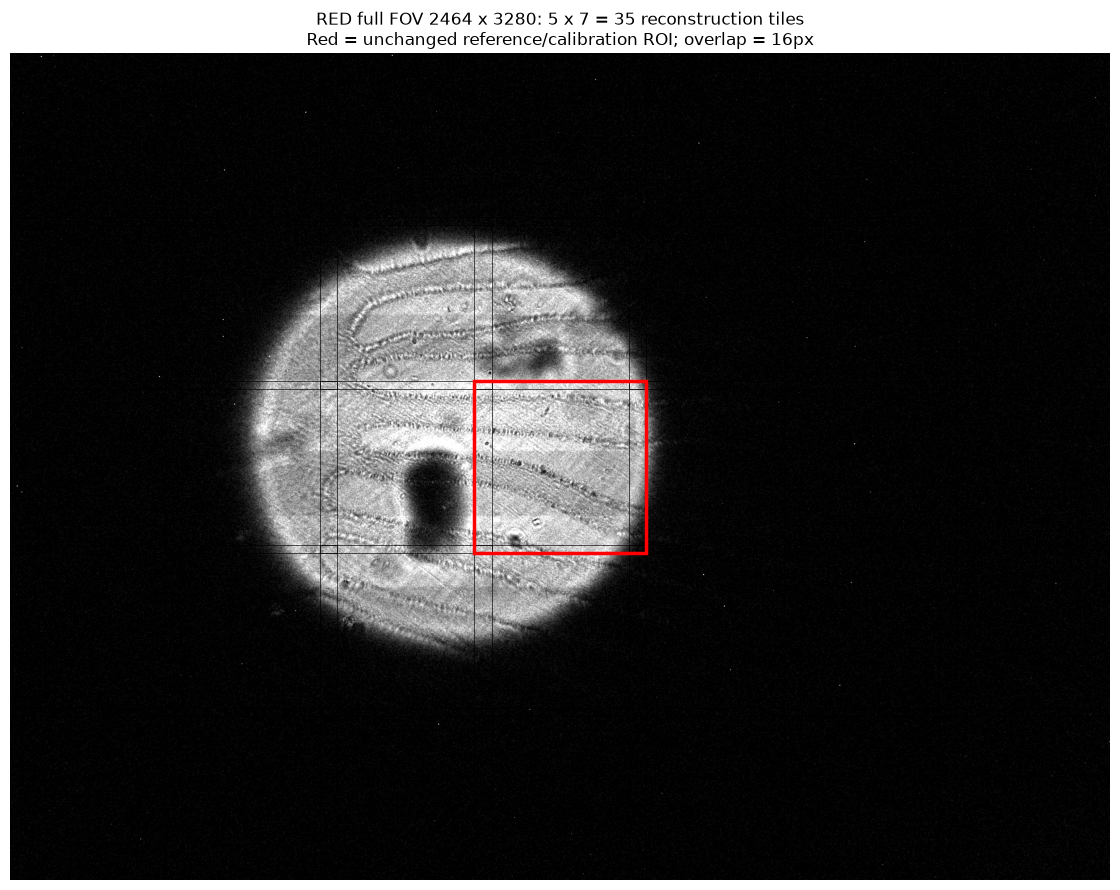


ACTIVE COLOUR: GREEN
Data folder: C:\Users\kshlo\Desktop\FPM\John Code\Sequential\GREEN
Sensor RGB channel index: 1
Illumination wavelength: 0.53 um
Results folder: results_green_full_fov_fast_balanced
Metadata selected: C:\Users\kshlo\Desktop\FPM\John Code\Sequential\GREEN\metadata.csv
Capture validation: 256 images and the exact 16 x 16 centre-out spiral.
Shell 6/7 gains: [2.0] [2.0]


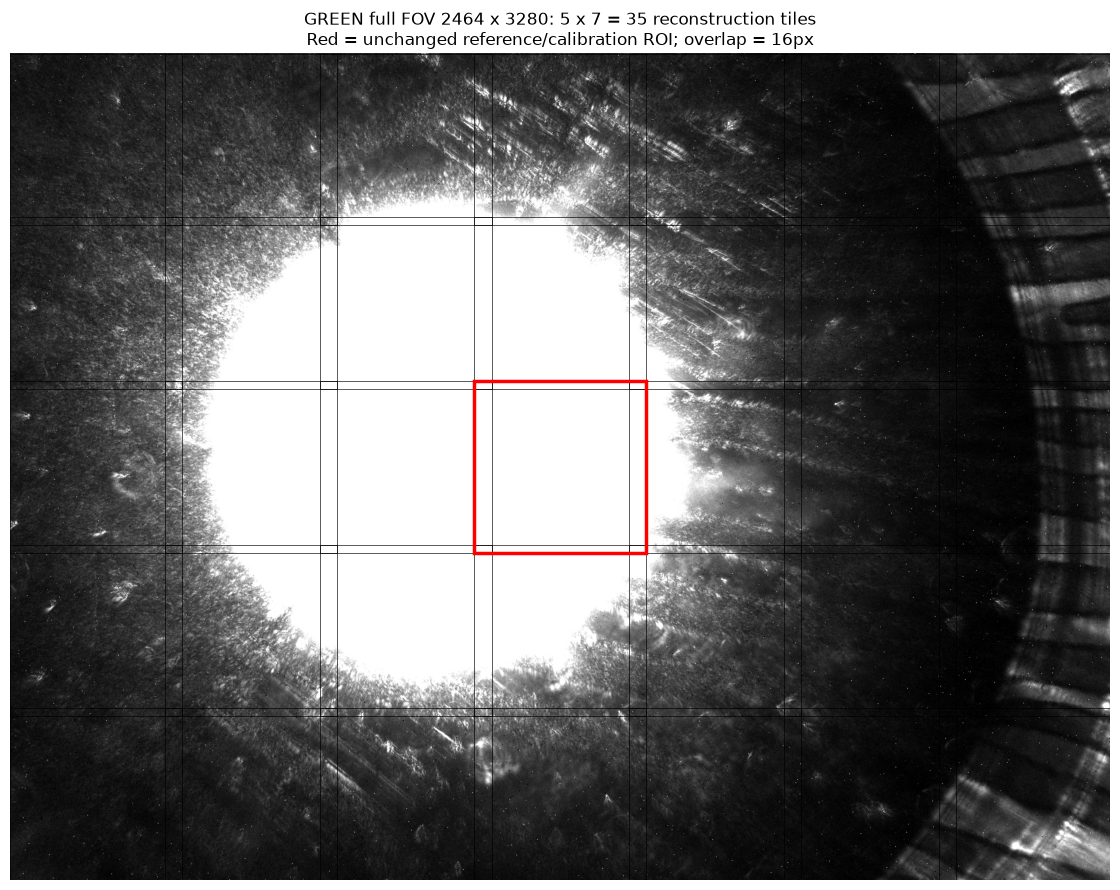


ACTIVE COLOUR: BLUE
Data folder: C:\Users\kshlo\Desktop\FPM\John Code\Sequential\BLUE
Sensor RGB channel index: 2
Illumination wavelength: 0.47 um
Results folder: results_blue_full_fov_fast_balanced
Metadata selected: C:\Users\kshlo\Desktop\FPM\John Code\Sequential\BLUE\metadata.csv
Capture validation: 256 images and the exact 16 x 16 centre-out spiral.
Shell 6/7 gains: [4.0] [4.0]


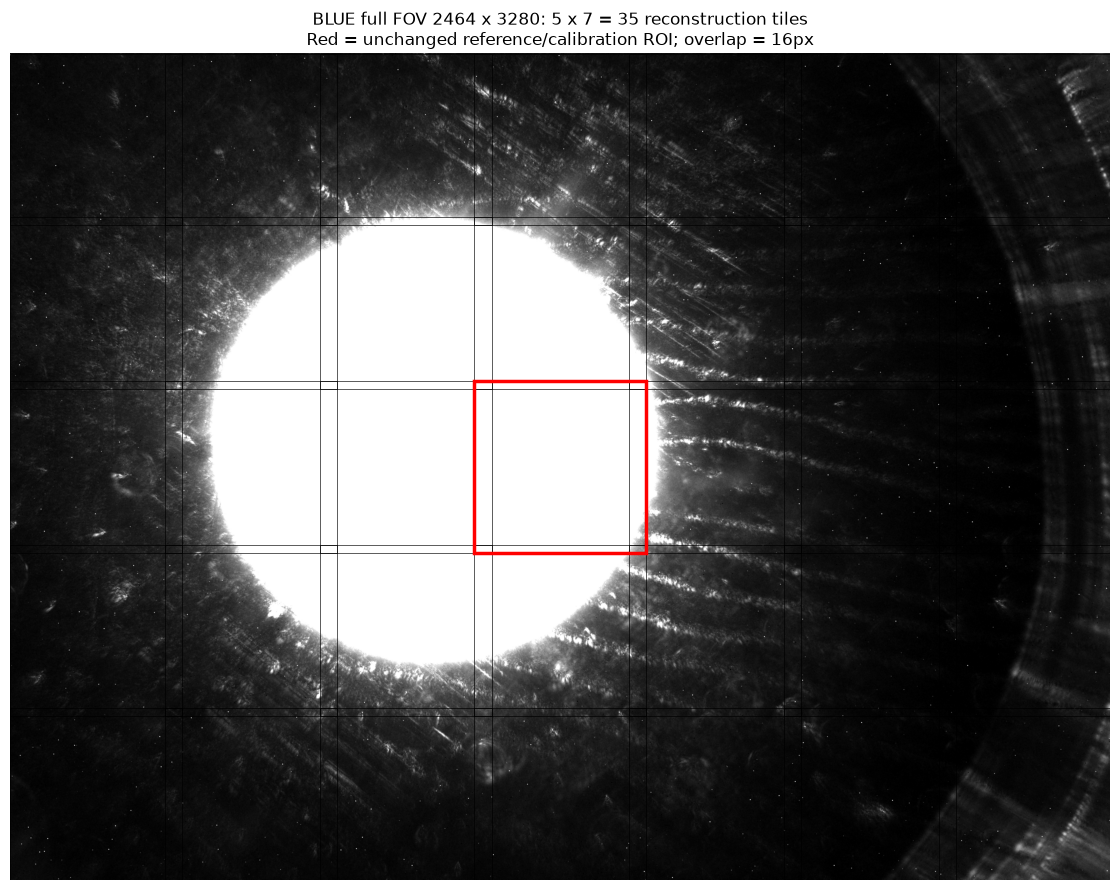

{'red': {'seed_path': 'C:\\Users\\kshlo\\Desktop\\FPM\\John Code\\Sequential\\RED\\ImgNo_0_colorred.dng',
  'frame_shape': (2464, 3280),
  'tile_size': 512,
  'tile_overlap_px': 16,
  'row_starts': [0, 488, 976, 1464, 1952],
  'column_starts': [0, 461, 923, 1384, 1845, 2307, 2768],
  'tile_count': 35,
  'reference_tile': (976, 1384, 512, 512)},
 'green': {'seed_path': 'C:\\Users\\kshlo\\Desktop\\FPM\\John Code\\Sequential\\GREEN\\ImgNo_0_colorgreen.dng',
  'frame_shape': (2464, 3280),
  'tile_size': 512,
  'tile_overlap_px': 16,
  'row_starts': [0, 488, 976, 1464, 1952],
  'column_starts': [0, 461, 923, 1384, 1845, 2307, 2768],
  'tile_count': 35,
  'reference_tile': (976, 1384, 512, 512)},
 'blue': {'seed_path': 'C:\\Users\\kshlo\\Desktop\\FPM\\John Code\\Sequential\\BLUE\\ImgNo_0_colorblue.dng',
  'frame_shape': (2464, 3280),
  'tile_size': 512,
  'tile_overlap_px': 16,
  'row_starts': [0, 488, 976, 1464, 1952],
  'column_starts': [0, 461, 923, 1384, 1845, 2307, 2768],
  'tile_count'

In [8]:
rgb_full_fov_preview_summary = {}

for colour in RGB_RUN_ORDER:
    set_active_colour(colour)

    if not DATA_DIR.exists():
        raise FileNotFoundError(
            f"{colour.upper()} dataset folder does not exist: {DATA_DIR}"
        )

    rgb_full_fov_preview_summary[colour] = preview_full_fov_tiling()

rgb_full_fov_preview_summary


## 9. Full-FOV RGB registration and fusion

Green remains the reference channel. The complete rectangular aspect ratio is preserved while red and blue are registered and mapped into the final RGB image.


In [9]:
# =============================================================================
# Full-FOV RGB channel loading, registration and fusion
# =============================================================================

def full_fov_reconstruction_output_dir(
    colour: str,
) -> Path:
    configuration = RGB_CHANNELS[colour]
    data_dir = Path(configuration["data_dir"])
    metadata_csv = find_metadata_csv(data_dir)
    return metadata_csv.parent / str(
        configuration["results_folder_name"]
    )


def full_fov_reconstructed_amplitude_path(
    colour: str,
) -> Path:
    return (
        full_fov_reconstruction_output_dir(colour)
        / "full_fov_reconstruction_amplitude.npy"
    )


def load_full_fov_reconstructed_amplitude(
    colour: str,
) -> np.ndarray:
    path = full_fov_reconstructed_amplitude_path(colour)
    if not path.exists():
        raise FileNotFoundError(
            f"Missing full-FOV reconstructed amplitude for {colour}: {path}"
        )
    return np.load(path, mmap_mode="r")


def robust_unit_range(
    image: np.ndarray,
    lower_percentile: float = 0.5,
    upper_percentile: float = 99.7,
) -> np.ndarray:
    image = np.asarray(
        image,
        dtype=np.float32,
    )

    lower = float(
        np.percentile(
            image,
            lower_percentile,
        )
    )

    upper = float(
        np.percentile(
            image,
            upper_percentile,
        )
    )

    return np.clip(
        (image - lower)
        / max(
            upper - lower,
            1.0e-12,
        ),
        0.0,
        1.0,
    ).astype(np.float32)

def resize_to_shape(
    image: np.ndarray,
    target_shape: Tuple[int, int],
) -> np.ndarray:
    target_height, target_width = (
        target_shape
    )

    if image.shape == target_shape:
        return np.asarray(
            image,
            dtype=np.float32,
        )

    if cv2 is not None:
        return cv2.resize(
            np.asarray(
                image,
                dtype=np.float32,
            ),
            (
                target_width,
                target_height,
            ),
            interpolation=cv2.INTER_CUBIC,
        ).astype(np.float32)

    pil_image = Image.fromarray(
        np.asarray(
            image,
            dtype=np.float32,
        ),
        mode="F",
    )

    resized = pil_image.resize(
        (
            target_width,
            target_height,
        ),
        resample=Image.Resampling.BICUBIC,
    )

    return np.asarray(
        resized,
        dtype=np.float32,
    )

def align_to_green(
    moving: np.ndarray,
    reference: np.ndarray,
    colour: str,
) -> Tuple[np.ndarray, Dict]:
    """
    Align one reconstructed colour to the green reference.

    SIFT affine registration is attempted first, matching the paper's final
    colour assembly approach. ECC affine and phase-correlation translation are
    used as fallbacks.
    """
    moving = np.asarray(
        moving,
        dtype=np.float32,
    )
    reference = np.asarray(
        reference,
        dtype=np.float32,
    )

    if moving.shape != reference.shape:
        moving = resize_to_shape(
            moving,
            reference.shape,
        )

    if cv2 is None:
        print(
            f"OpenCV unavailable: {colour} was resized "
            "but not feature-registered."
        )
        return moving, {
            "method": "resize_only",
            "matrix": None,
        }

    reference_normalised = robust_unit_range(
        reference,
        1.0,
        99.0,
    )

    moving_normalised = robust_unit_range(
        moving,
        1.0,
        99.0,
    )

    reference_uint8 = np.round(
        reference_normalised * 255.0
    ).astype(np.uint8)

    moving_uint8 = np.round(
        moving_normalised * 255.0
    ).astype(np.uint8)

    height, width = reference.shape

    # 1. SIFT feature registration.
    if hasattr(cv2, "SIFT_create"):
        try:
            sift = cv2.SIFT_create()

            moving_keypoints, moving_descriptors = (
                sift.detectAndCompute(
                    moving_uint8,
                    None,
                )
            )

            reference_keypoints, reference_descriptors = (
                sift.detectAndCompute(
                    reference_uint8,
                    None,
                )
            )

            if (
                moving_descriptors is not None
                and reference_descriptors is not None
                and len(moving_keypoints) >= 8
                and len(reference_keypoints) >= 8
            ):
                matcher = cv2.BFMatcher(
                    cv2.NORM_L2,
                )

                paired_matches = matcher.knnMatch(
                    moving_descriptors,
                    reference_descriptors,
                    k=2,
                )

                good_matches = [
                    first
                    for first, second
                    in paired_matches
                    if (
                        second.distance > 0
                        and first.distance
                        < 0.75 * second.distance
                    )
                ]

                if len(good_matches) >= 8:
                    moving_points = np.float32(
                        [
                            moving_keypoints[
                                match.queryIdx
                            ].pt
                            for match in good_matches
                        ]
                    ).reshape(-1, 1, 2)

                    reference_points = np.float32(
                        [
                            reference_keypoints[
                                match.trainIdx
                            ].pt
                            for match in good_matches
                        ]
                    ).reshape(-1, 1, 2)

                    affine_matrix, inlier_mask = (
                        cv2.estimateAffinePartial2D(
                            moving_points,
                            reference_points,
                            method=cv2.RANSAC,
                            ransacReprojThreshold=3.0,
                        )
                    )

                    if affine_matrix is not None:
                        aligned = cv2.warpAffine(
                            moving,
                            affine_matrix,
                            (
                                width,
                                height,
                            ),
                            flags=cv2.INTER_CUBIC,
                            borderMode=cv2.BORDER_REFLECT,
                        )

                        inlier_count = (
                            int(
                                np.sum(inlier_mask)
                            )
                            if inlier_mask is not None
                            else None
                        )

                        print(
                            f"{colour.upper()} alignment: "
                            f"SIFT affine, "
                            f"{len(good_matches)} matches, "
                            f"{inlier_count} inliers."
                        )

                        return aligned.astype(
                            np.float32
                        ), {
                            "method": "sift_affine",
                            "matrix": (
                                affine_matrix.tolist()
                            ),
                            "matches": len(
                                good_matches
                            ),
                            "inliers": inlier_count,
                        }
        except Exception as error:
            print(
                f"{colour.upper()} SIFT alignment "
                f"failed: {error}"
            )

    # 2. ECC affine fallback.
    try:
        warp_matrix = np.eye(
            2,
            3,
            dtype=np.float32,
        )

        criteria = (
            cv2.TERM_CRITERIA_EPS
            | cv2.TERM_CRITERIA_COUNT,
            250,
            1.0e-7,
        )

        correlation, warp_matrix = (
            cv2.findTransformECC(
                reference_normalised,
                moving_normalised,
                warp_matrix,
                cv2.MOTION_AFFINE,
                criteria,
                None,
                5,
            )
        )

        aligned = cv2.warpAffine(
            moving,
            warp_matrix,
            (
                width,
                height,
            ),
            flags=(
                cv2.INTER_CUBIC
                | cv2.WARP_INVERSE_MAP
            ),
            borderMode=cv2.BORDER_REFLECT,
        )

        print(
            f"{colour.upper()} alignment: "
            f"ECC affine, correlation={correlation:.5f}."
        )

        return aligned.astype(
            np.float32
        ), {
            "method": "ecc_affine",
            "matrix": warp_matrix.tolist(),
            "correlation": float(
                correlation
            ),
        }

    except Exception as error:
        print(
            f"{colour.upper()} ECC alignment "
            f"failed: {error}"
        )

    # 3. Translation-only phase-correlation fallback.
    try:
        shift, response = cv2.phaseCorrelate(
            moving_normalised,
            reference_normalised,
        )

        translation_matrix = np.float32(
            [
                [1.0, 0.0, shift[0]],
                [0.0, 1.0, shift[1]],
            ]
        )

        aligned = cv2.warpAffine(
            moving,
            translation_matrix,
            (
                width,
                height,
            ),
            flags=cv2.INTER_CUBIC,
            borderMode=cv2.BORDER_REFLECT,
        )

        print(
            f"{colour.upper()} alignment: "
            f"phase-correlation translation, "
            f"shift={shift}, response={response:.5f}."
        )

        return aligned.astype(
            np.float32
        ), {
            "method": "phase_translation",
            "matrix": (
                translation_matrix.tolist()
            ),
            "shift": [
                float(shift[0]),
                float(shift[1]),
            ],
            "response": float(response),
        }

    except Exception as error:
        print(
            f"{colour.upper()} translation alignment "
            f"failed: {error}"
        )

    print(
        f"{colour.upper()} alignment: resize only."
    )

    return moving, {
        "method": "resize_only",
        "matrix": None,
    }


def save_full_fov_rgb_composite(
    amplitudes: Dict[str, np.ndarray],
    run_summaries: Dict[str, Dict],
) -> Dict:
    RGB_COMBINED_RESULTS_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    # The stitched channels can have different super-resolution sizes because
    # wavelength changes the recovered object-grid size. Green remains the
    # registration reference, exactly as in the centre-patch RGB notebook, but
    # its rectangular full-FOV aspect ratio is preserved.
    target_shape = tuple(
        int(value)
        for value in amplitudes["green"].shape
    )

    resized = {
        colour: resize_to_shape(
            image,
            target_shape,
        )
        for colour, image
        in amplitudes.items()
    }

    green_reference = resized["green"]

    aligned_red, red_alignment = (
        align_to_green(
            resized["red"],
            green_reference,
            "red",
        )
    )

    aligned_blue, blue_alignment = (
        align_to_green(
            resized["blue"],
            green_reference,
            "blue",
        )
    )

    aligned = {
        "red": aligned_red,
        "green": green_reference,
        "blue": aligned_blue,
    }

    # Balanced colour display. Independent channel scaling compensates for
    # different LED power and Bayer spectral sensitivity. This is a display
    # composite, not an absolute radiometric colour measurement.
    display_channels = {
        colour: robust_unit_range(
            image,
            0.5,
            99.7,
        ) ** 0.90
        for colour, image
        in aligned.items()
    }

    rgb_float = np.stack(
        [
            display_channels["red"],
            display_channels["green"],
            display_channels["blue"],
        ],
        axis=-1,
    )

    rgb_uint8 = np.round(
        np.clip(
            rgb_float,
            0.0,
            1.0,
        )
        * 255.0
    ).astype(np.uint8)

    rgb_uint16 = np.round(
        np.clip(
            rgb_float,
            0.0,
            1.0,
        )
        * 65535.0
    ).astype(np.uint16)

    Image.fromarray(
        rgb_uint8,
        mode="RGB",
    ).save(
        RGB_COMBINED_RESULTS_DIR
        / "rgb_full_fov_reconstruction_aligned_balanced.png"
    )

    sixteen_bit_path = (
        RGB_COMBINED_RESULTS_DIR
        / "rgb_full_fov_reconstruction_aligned_balanced_16bit.png"
    )
    if cv2 is not None:
        cv2.imwrite(
            str(sixteen_bit_path),
            cv2.cvtColor(
                rgb_uint16,
                cv2.COLOR_RGB2BGR,
            ),
        )
    else:
        # Pillow does not reliably write three-channel 16-bit PNG files.
        # The floating-point RGB array below remains the lossless fallback.
        print(
            "OpenCV unavailable: skipped 16-bit RGB PNG. "
            "The float RGB NPY file is still saved."
        )

    np.save(
        RGB_COMBINED_RESULTS_DIR
        / "rgb_full_fov_reconstruction_aligned_float.npy",
        rgb_float.astype(np.float32),
    )

    for colour, image in aligned.items():
        np.save(
            RGB_COMBINED_RESULTS_DIR
            / f"aligned_{colour}_amplitude.npy",
            image.astype(np.float32),
        )

        save_uint8(
            RGB_COMBINED_RESULTS_DIR
            / f"aligned_{colour}_amplitude.png",
            image,
            0.5,
            99.7,
            0.9,
        )

    # Contact sheet with the three aligned channels and final RGB image.
    fig, axes = plt.subplots(
        1,
        4,
        figsize=(20, 5),
    )

    axes[0].imshow(
        display_channels["red"],
        cmap="gray",
    )
    axes[0].set_title("Aligned red amplitude")

    axes[1].imshow(
        display_channels["green"],
        cmap="gray",
    )
    axes[1].set_title("Green amplitude reference")

    axes[2].imshow(
        display_channels["blue"],
        cmap="gray",
    )
    axes[2].set_title("Aligned blue amplitude")

    axes[3].imshow(rgb_uint8)
    axes[3].set_title("Final balanced RGB full-FOV reconstruction")

    for axis in axes:
        axis.axis("off")

    fig.tight_layout()

    fig.savefig(
        RGB_COMBINED_RESULTS_DIR
        / "rgb_full_fov_reconstruction_contact_sheet.png",
        dpi=180,
    )

    plt.close(fig)

    fusion_summary = {
        "method": (
            "independent_full_fov_monochromatic_fpm_then_alignment_and_rgb_mapping"
        ),
        "reference_channel": "green",
        "target_shape": list(
            target_shape
        ),
        "red_alignment": red_alignment,
        "blue_alignment": blue_alignment,
        "wavelengths_um": {
            colour: float(
                RGB_CHANNELS[colour][
                    "wavelength_um"
                ]
            )
            for colour in RGB_RUN_ORDER
        },
        "sensor_channel_indices": {
            colour: int(
                RGB_CHANNELS[colour][
                    "sensor_channel_index"
                ]
            )
            for colour in RGB_RUN_ORDER
        },
        "display_scaling": (
            "independent 0.5-99.7 percentile scaling per channel"
        ),
        "radiometric_colour_warning": (
            "The balanced RGB PNG is intended for visualisation. "
            "Absolute colour requires calibrated LED spectra, camera "
            "spectral response and radiometric colour correction."
        ),
        "individual_run_summaries": (
            run_summaries
        ),
    }

    with (
        RGB_COMBINED_RESULTS_DIR
        / "rgb_full_fov_fusion_summary.json"
    ).open(
        "w",
        encoding="utf-8",
    ) as handle:
        json.dump(
            fusion_summary,
            handle,
            indent=2,
        )

    return fusion_summary

### Effective balanced settings

This cell confirms the number of LEDs, EPRY passes and whether GPU acceleration is available before the long run.


In [10]:
selected_indices_preview = _selected_reconstruction_indices()
print("Selected LEDs:", len(selected_indices_preview))
print("Maximum shell:", MAX_RECONSTRUCTION_SHELL)
print("EPRY stages:", EPRY_STAGES)
print("Iterations per stage:", ITERATIONS_PER_STAGE)
print("Total LED updates per tile:", len(selected_indices_preview) * EPRY_STAGES * ITERATIONS_PER_STAGE)
print("GPU backend available:", _gpu_available())
print("CPU FFT workers:", FFT_WORKERS)


Selected LEDs: 196
Maximum shell: 6
EPRY stages: 2
Iterations per stage: 4
Total LED updates per tile: 1568
GPU backend available: True
CPU FFT workers: -1


## 10. Run the fast balanced RGB reconstruction

The run is resumable. A cache remains on disk if you interrupt midway and is removed only after that colour has been completely reconstructed and stitched. Completed tile files are also reused when the cell is run again.


In [11]:
# Validate all required dataset folders first.
for colour in RGB_RUN_ORDER:
    colour_folder = Path(
        RGB_CHANNELS[colour]["data_dir"]
    )
    if not colour_folder.exists():
        raise FileNotFoundError(
            f"{colour.upper()} dataset folder does not exist: {colour_folder}"
        )

rgb_full_fov_run_summaries: Dict[str, Dict] = {}

for colour in RGB_RUN_ORDER:
    set_active_colour(colour)

    amplitude_path = full_fov_reconstructed_amplitude_path(colour)
    should_reconstruct = colour in COLOURS_TO_RECONSTRUCT

    if (
        REUSE_EXISTING_FULL_FOV_RECONSTRUCTIONS
        and amplitude_path.exists()
    ):
        print(
            f"Reusing existing {colour.upper()} full-FOV reconstruction: "
            f"{amplitude_path}"
        )
        summary_path = (
            full_fov_reconstruction_output_dir(colour)
            / "full_fov_run_summary.json"
        )
        if summary_path.exists():
            with summary_path.open("r", encoding="utf-8") as handle:
                rgb_full_fov_run_summaries[colour] = json.load(handle)
        else:
            rgb_full_fov_run_summaries[colour] = {
                "status": "existing full-FOV reconstruction reused"
            }
        continue

    if not should_reconstruct:
        if not amplitude_path.exists():
            raise FileNotFoundError(
                f"{colour.upper()} was excluded from COLOURS_TO_RECONSTRUCT, "
                f"but no existing full-FOV result was found: {amplitude_path}"
            )
        rgb_full_fov_run_summaries[colour] = {
            "status": "existing full-FOV reconstruction selected"
        }
        continue

    rgb_full_fov_run_summaries[colour] = (
        run_full_fov_reconstruction_for_active_colour()
    )

rgb_full_fov_amplitudes = {
    colour: load_full_fov_reconstructed_amplitude(colour)
    for colour in RGB_RUN_ORDER
}

rgb_full_fov_fusion_summary = save_full_fov_rgb_composite(
    rgb_full_fov_amplitudes,
    rgb_full_fov_run_summaries,
)

print()
print("=" * 80)
print("RGB FULL-FOV RECONSTRUCTION COMPLETE")
print(
    "Final RGB image:",
    RGB_COMBINED_RESULTS_DIR
    / "rgb_full_fov_reconstruction_aligned_balanced.png",
)
print(
    "16-bit RGB image:",
    RGB_COMBINED_RESULTS_DIR
    / "rgb_full_fov_reconstruction_aligned_balanced_16bit.png",
)
print(
    "Contact sheet:",
    RGB_COMBINED_RESULTS_DIR
    / "rgb_full_fov_reconstruction_contact_sheet.png",
)
print("=" * 80)

rgb_full_fov_fusion_summary


ACTIVE COLOUR: RED
Data folder: C:\Users\kshlo\Desktop\FPM\John Code\Sequential\RED
Sensor RGB channel index: 0
Illumination wavelength: 0.63 um
Results folder: results_red_full_fov_fast_balanced
Object-plane pixel size: 1.0546 um
Sampling factor: 3.144
Predicted adjacent frequency overlap: 64.7%
Active colour: RED
Maximum reconstruction shell: 6
Selected LED count: 196
EPRY passes: 2 stages x 4 iterations
DNG preprocessing: one pass per colour, then cached
Metadata selected: C:\Users\kshlo\Desktop\FPM\John Code\Sequential\RED\metadata.csv
Capture validation: 256 images and the exact 16 x 16 centre-out spiral.
Shell 6/7 gains: [4.0] [4.0]
Native FOV: 2464 x 3280; tiles: 5 x 7 = 35
Row starts: [0, 488, 976, 1464, 1952]
Column starts: [0, 461, 923, 1384, 1845, 2307, 2768]
Loading 8 dark frames once...
Preprocessing cache complete: C:\Users\kshlo\Desktop\FPM\John Code\Sequential\RED\results_red_full_fov_fast_balanced\preprocessed_cache_shell_6_float32
centre=(7.0, 7.0), signs=(1, 1), sta

{'method': 'independent_full_fov_monochromatic_fpm_then_alignment_and_rgb_mapping',
 'reference_channel': 'green',
 'target_shape': [7132, 9494],
 'red_alignment': {'method': 'ecc_affine',
  'matrix': [[1.0004326105117798,
    2.2087946490501054e-05,
    -0.20020288228988647],
   [6.210662832017988e-05, 0.9999458193778992, 0.8823580741882324]],
  'correlation': 0.40938726203058534},
 'blue_alignment': {'method': 'ecc_affine',
  'matrix': [[1.0003056526184082, -0.0001896387111628428, -0.5292515158653259],
   [-3.402264337637462e-05, 1.0004777908325195, -1.1069557666778564]],
  'correlation': 0.4736062771794075},
 'wavelengths_um': {'red': 0.63, 'green': 0.53, 'blue': 0.47},
 'sensor_channel_indices': {'red': 0, 'green': 1, 'blue': 2},
 'display_scaling': 'independent 0.5-99.7 percentile scaling per channel',
 'radiometric_colour_warning': 'The balanced RGB PNG is intended for visualisation. Absolute colour requires calibrated LED spectra, camera spectral response and radiometric colour 